<div style="padding:32px 36px;border-radius:16px;background:linear-gradient(135deg,#102A43 0%,#243B53 100%);color:#F7F4EC;margin-bottom:24px;">
  <div style="font-size:13px;letter-spacing:0.16em;text-transform:uppercase;color:#D4A44C;font-weight:700;">Article reproduction notebook · ConflictLens</div>
  <h1 style="margin:10px 0 8px 0;font-size:40px;font-weight:700;color:#FFFFFF;">Two years, almost the same toll. Not the same shape.</h1>
  <p style="margin:0;max-width:800px;font-size:18px;line-height:1.55;color:#D9E2EC;">Recompute every article-facing number, defend the year-pair selection, measure the panel-level relationship, and export five publication figures without manually typed analytical values.</p>
  <div style="margin-top:24px;padding-top:16px;border-top:1px solid rgba(255,255,255,0.20);font-size:13px;color:#BCCCDC;">UCDP Organized Violence v26.1 · analysis-unit-year panel · 1989–2025 · descriptive, non-causal</div>
</div>

**Notebook contract**  
Question → Method → Result → Interpretation → Decision. The analytical unit is `analysis_unit_id + year`; analytical-unit-year contributions are statistical components of an annual total, not attributions of responsibility.

## Navigation

0. [Setup](#setup)
1. [Analytical frame](#analytical-frame)
2. [Per-year structure table](#year-structure)
3. [Pair scan and selection rule](#pair-scan)
4. [Panel-level relationship](#panel-relationship)
5. [The four focal years](#focal-years)
6. [Publication figures and controls](#figures)
7. [Validation summary](#validation)
8. [Next steps and debt register](#next-steps)

<a id="setup"></a>

## 00 — Setup

**Question.** Can this notebook execute against the repository contract without hidden local assumptions?  
**Method.** Resolve the repository root, load the shared article art-direction module, report fonts and package versions, and record the source commit.  
**Decision.** Figure styling is centralised in `notebooks/_shared/conflictlens_article_style.py`; analytical logic remains in this notebook.

In [1]:
from __future__ import annotations

import importlib.metadata as importlib_metadata
import importlib.util
import json
import math
import platform
import re
import subprocess
import sys
from datetime import datetime, timezone
from itertools import combinations
from pathlib import Path

import numpy as np
import pandas as pd
from IPython.display import HTML, Markdown, display

REQUIRED_MODULES = {
    "pandas": "pandas",
    "numpy": "numpy",
    "matplotlib": "matplotlib",
    "pyarrow": "pyarrow",
    "PIL": "pillow",
}
missing = [module for module in REQUIRED_MODULES if importlib.util.find_spec(module) is None]
if missing:
    raise ImportError("Missing required package(s): " + ", ".join(missing))

import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter, FixedLocator
from PIL import Image

pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 180)
pd.set_option("display.max_colwidth", 160)


def locate_project_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / "pyproject.toml").exists() and (candidate / "notebooks").exists():
            return candidate
    raise FileNotFoundError("Could not locate the ConflictLens repository root.")


PROJECT_ROOT = locate_project_root(Path.cwd())
SHARED_DIR = PROJECT_ROOT / "notebooks" / "_shared"
if str(SHARED_DIR) not in sys.path:
    sys.path.insert(0, str(SHARED_DIR))

from conflictlens_article_style import (  # noqa: E402
    COLORS,
    FIGURE_PROFILES,
    apply_conflictlens_article_style,
    export_publication_figure,
    style_axis,
)

FONTS = apply_conflictlens_article_style()
SANS_USED = FONTS["sans_used"]
MONO_USED = FONTS["mono_used"]

START_YEAR = 1989
END_YEAR = 2025
PERIOD = f"{START_YEAR}-{END_YEAR}"
ARTICLE_SLUG = "two-years-almost-the-same-toll"
NOTEBOOK_NAME = "01b_two_years_almost_the_same_toll.ipynb"
PANEL_FILENAME = "02_analysis_unit_year_panel_analysis_ready.parquet"
UNIVERSE = "analysis_conflict_universe"
GUARD = "unit_exists_in_year"
MEASURE = "ucdp_ov_total_deaths_best_zf"
GRAIN = ["analysis_unit_id", "year"]
ARCHIVE_SOURCE_COMMIT = "2354f0ad170dff77074279b61297ca7bc4147005"
DECISION_LOG_URL = "https://app.notion.com/p/39c44644ec14815baea2fd495dcde261"

FIGURE_DIR = PROJECT_ROOT / "figures" / ARTICLE_SLUG
VALIDATION_DIR = FIGURE_DIR / "validation"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
VALIDATION_DIR.mkdir(parents=True, exist_ok=True)


def detect_source_commit() -> tuple[str, str]:
    if (PROJECT_ROOT / ".git").exists():
        try:
            commit = subprocess.check_output(
                ["git", "-C", str(PROJECT_ROOT), "rev-parse", "HEAD"],
                text=True,
                stderr=subprocess.STDOUT,
            ).strip()
            return commit, "Detected from Git metadata."
        except Exception as exc:
            return ARCHIVE_SOURCE_COMMIT, f"Git detection failed; archive commit retained ({exc!r})."
    return ARCHIVE_SOURCE_COMMIT, "Recorded from the supplied repository archive."


SOURCE_COMMIT, SOURCE_COMMIT_STATUS = detect_source_commit()


def display_note(title: str, text: str, kind: str = "info") -> None:
    palette = {
        "info": (COLORS["info_ink"], "#DCEEFF"),
        "success": (COLORS["ok"], "#DFF3E4"),
        "warning": (COLORS["caution_ink"], "#FFF3CD"),
        "error": (COLORS["limit_ink"], "#FDE2E2"),
    }
    border, background = palette[kind]
    display(HTML(
        f"<div style='box-sizing:border-box;width:100%;padding:15px 18px;border-left:5px solid {border};"
        f"border-radius:6px;background:{background};color:{COLORS['ink']};line-height:1.55;margin:14px 0;'>"
        f"<strong>{title}</strong><br>{text}</div>"
    ))


def fmt_int(value: float | int) -> str:
    return f"{int(round(float(value))):,}"


def fmt_pct(value: float, decimals: int = 1) -> str:
    return f"{float(value) * 100:.{decimals}f}%"


def article_label(unit_id: str, label: str) -> str:
    presentation = {"SYR": "Syria"}
    return presentation.get(str(unit_id), str(label))


checks: list[dict[str, object]] = []


def record_check(check_id: str, passed: bool, detail: str) -> None:
    row = {"check": check_id, "passed": bool(passed), "detail": detail}
    checks.append(row)
    if not passed:
        raise AssertionError(f"{check_id} failed: {detail}")


package_versions = {
    module: importlib_metadata.version(package)
    for module, package in REQUIRED_MODULES.items()
}

NOTEBOOK_METADATA_PATH = FIGURE_DIR / "notebook_metadata.json"
notebook_metadata = {
    "article_slug": ARTICLE_SLUG,
    "notebook": f"notebooks/articles/{NOTEBOOK_NAME}",
    "source_commit": SOURCE_COMMIT,
    "source_commit_status": SOURCE_COMMIT_STATUS,
    "python": sys.version.split()[0],
    "platform": platform.platform(),
    "package_versions": package_versions,
    "font_sans": SANS_USED,
    "font_mono": MONO_USED,
    "ibm_plex_available": FONTS["ibm_plex_available"],
    "decision_log_url": DECISION_LOG_URL,
    "generated_at_utc": datetime.now(timezone.utc).isoformat(),
}
NOTEBOOK_METADATA_PATH.write_text(json.dumps(notebook_metadata, indent=2, ensure_ascii=False), encoding="utf-8")

display_note(
    "Execution environment",
    f"Python <code>{sys.version.split()[0]}</code> · pandas <code>{package_versions['pandas']}</code> · "
    f"matplotlib <code>{package_versions['matplotlib']}</code><br>"
    f"Resolved fonts: <code>{SANS_USED}</code> / <code>{MONO_USED}</code> · "
    f"IBM Plex available: <code>{FONTS['ibm_plex_available']}</code><br>"
    f"Source commit: <code>{SOURCE_COMMIT}</code> · {SOURCE_COMMIT_STATUS}",
    kind="info",
)

mkdir -p failed for path /root/.config/matplotlib: [Errno 30] Read-only file system: '/root/.config'
Matplotlib created a temporary cache directory at /tmp/matplotlib-3nzcidrn because there was an issue with the default path ({configdir}); it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.


<a id="analytical-frame"></a>

## 01 — Analytical frame

**Question.** What is the exact universe on which all article claims are built?  
**Method.** Load the validated analysis-unit-year panel, retain the conflict universe, apply the unit-existence guard first, then create a local arithmetic measure in which remaining missing values are zero only after that guard. Preserve a flag identifying those originally missing values.  
**Risk.** A unit that does not exist in a year is not a zero. The order of operations is therefore load → universe → existence guard → arithmetic fill, never fill → filter.

In [2]:
PANEL_CANDIDATES = [
    PROJECT_ROOT / "outputs" / "analysis_ready" / PANEL_FILENAME,
    PROJECT_ROOT / "outputs" / PANEL_FILENAME,
    PROJECT_ROOT / PANEL_FILENAME,
]
PANEL_PATH = next((path for path in PANEL_CANDIDATES if path.exists()), None)
if PANEL_PATH is None:
    raise FileNotFoundError("Missing private input: " + PANEL_FILENAME)

required_columns = {
    "analysis_unit_id",
    "analysis_unit_label",
    "year",
    UNIVERSE,
    GUARD,
    MEASURE,
    "ucdp_ov_any_organized_violence_zf",
}
panel_raw = pd.read_parquet(PANEL_PATH)
missing_columns = sorted(required_columns.difference(panel_raw.columns))
if missing_columns:
    raise AssertionError(f"Panel is missing required columns: {missing_columns}")
if panel_raw.duplicated(GRAIN).any():
    raise AssertionError("The canonical analysis_unit_id + year key is not unique.")

frame = panel_raw.loc[
    panel_raw[UNIVERSE].eq(True)
    & panel_raw[GUARD].eq(True)
    & panel_raw["year"].between(START_YEAR, END_YEAR),
    [
        "analysis_unit_id",
        "analysis_unit_label",
        "year",
        MEASURE,
        "ucdp_ov_any_organized_violence_zf",
    ],
].copy()
frame["measure_was_missing_after_guard"] = frame[MEASURE].isna()
raw_missing_after_guard = int(frame["measure_was_missing_after_guard"].sum())
frame[MEASURE] = pd.to_numeric(frame[MEASURE], errors="coerce").fillna(0.0)

record_check("A01", len(frame) == 9_068, f"guarded conflict-universe rows={len(frame):,}")
record_check("A02", frame[MEASURE].notna().all(), f"remaining nulls={frame[MEASURE].isna().sum()}; raw post-guard nulls={raw_missing_after_guard:,}")

annual = (
    frame.groupby("year", as_index=False)[MEASURE]
    .sum()
    .rename(columns={MEASURE: "total"})
    .sort_values("year")
    .reset_index(drop=True)
)
annual["year"] = annual["year"].astype(int)
annual["total"] = annual["total"].astype(float)

prior_annual_path = PROJECT_ROOT / "figures" / "the-line-is-rising-but-not-everywhere" / "fig01_annual_ucdp_ov_total_deaths_1989_2025_data.csv"
prior_annual = pd.read_csv(prior_annual_path).rename(columns={"total_deaths": "total"})[["year", "total"]]
prior_annual["year"] = prior_annual["year"].astype(int)
prior_annual["total"] = prior_annual["total"].astype(float)

cross_notebook_exact = True
cross_notebook_detail = "exact match"
try:
    pd.testing.assert_frame_equal(
        annual.reset_index(drop=True),
        prior_annual.reset_index(drop=True),
        check_dtype=True,
        check_exact=True,
    )
except AssertionError as exc:
    cross_notebook_exact = False
    cross_notebook_detail = str(exc)
record_check("A03", cross_notebook_exact, cross_notebook_detail)

display(pd.DataFrame([
    {"input": str(PANEL_PATH.relative_to(PROJECT_ROOT)), "rows": len(panel_raw), "columns": panel_raw.shape[1]},
    {"input": "guarded analytical frame", "rows": len(frame), "columns": frame.shape[1]},
    {"input": "annual cross-notebook reference", "rows": len(prior_annual), "columns": prior_annual.shape[1]},
]))

display_note(
    "Decision — existence before zero",
    f"The existence guard is applied before the local arithmetic fill. The guarded frame contains "
    f"<strong>{raw_missing_after_guard:,}</strong> source-missing values; they are retained in an audit flag and cannot create positive contributors. "
    "All annual totals reproduce the prior article notebook exactly.",
    kind="success",
)

,input,rows,columns
0,outputs/analysis_ready/02_analysis_unit_year_panel_analysis_ready.parquet,9287,66
1,guarded analytical frame,9068,6
2,annual cross-notebook reference,37,2


**Result.** The analytical frame contains 9,068 guarded rows and reproduces the thirty-seven annual totals exactly.  
**Interpretation.** The article is downstream of the same annual series already published by ConflictLens; this notebook does not construct a competing total. The measure contains UCDP best estimates only.  
**Decision.** Positive-unit structure is computed only from `MEASURE > 0`, so arithmetic zeros and source-missing rows cannot become contributors. Lower and upper UCDP estimates are not present in this panel and are not propagated through the concentration measures; the article must disclose that limitation.

<a id="year-structure"></a>

## 02 — Per-year structure table

**Question.** How is each annual total distributed across its ranked positive contributors?  
**Method.** Within each year, sort positive units by recorded deaths, compute rank shares, the remainder outside the top three, HHI and its inverse (effective contributors).  
**Output.** `figures/two-years-almost-the-same-toll/year_structure.csv` is the reproducibility spine of the article.

In [3]:
year_rows: list[dict[str, object]] = []
share_sum_diagnostics: list[dict[str, float]] = []

for year, group in frame.groupby("year", sort=True):
    total = float(group[MEASURE].sum())
    positive = (
        group.loc[group[MEASURE].gt(0)]
        .sort_values([MEASURE, "analysis_unit_id"], ascending=[False, True])
        .reset_index(drop=True)
    )
    if len(positive) < 3 or total <= 0:
        raise AssertionError(f"Year {year} does not support the top-three structure contract.")
    shares = positive[MEASURE].to_numpy(dtype=float) / total
    row: dict[str, object] = {
        "year": int(year),
        "total": total,
        "n_positive": int(len(positive)),
    }
    for rank in (1, 2, 3):
        idx = rank - 1
        row[f"top{rank}"] = float(positive.loc[idx, MEASURE])
        row[f"top{rank}_id"] = str(positive.loc[idx, "analysis_unit_id"])
        row[f"top{rank}_label"] = str(positive.loc[idx, "analysis_unit_label"])
        row[f"s{rank}"] = float(shares[idx])
    row["top3_total"] = float(row["top1"] + row["top2"] + row["top3"])
    row["top3_share"] = float(row["s1"] + row["s2"] + row["s3"])
    row["rest3"] = float(total - row["top3_total"])
    row["rest3_share"] = float(row["rest3"] / total)
    row["hhi"] = float(np.square(shares).sum())
    row["eff_contrib"] = float(1.0 / row["hhi"])
    year_rows.append(row)
    share_sum_diagnostics.append({"year": int(year), "share_sum": float(shares.sum())})

year_structure = pd.DataFrame(year_rows).sort_values("year").reset_index(drop=True)
share_sums = pd.DataFrame(share_sum_diagnostics)
YEAR_STRUCTURE_PATH = FIGURE_DIR / "year_structure.csv"
year_structure.to_csv(YEAR_STRUCTURE_PATH, index=False)

recomposition = (
    year_structure[["top1", "top2", "top3", "rest3"]].sum(axis=1).round(6)
    == year_structure["total"].round(6)
).all()
record_check("A04", bool(recomposition), "top1 + top2 + top3 + rest3 equals total after 1e-6 rounding for all years")
record_check("A05", bool(np.allclose(share_sums["share_sum"], 1.0, atol=1e-9, rtol=0)), f"max error={float((share_sums['share_sum'] - 1).abs().max()):.3e}")
ranking_ok = ((year_structure["s1"] >= year_structure["s2"]) & (year_structure["s2"] >= year_structure["s3"])).all()
record_check("A06", bool(ranking_ok), "s1 >= s2 >= s3 for all years")
eff_ok = ((year_structure["eff_contrib"] >= 1) & (year_structure["eff_contrib"] <= year_structure["n_positive"] + 1e-12)).all()
record_check("A07", bool(eff_ok), "effective contributors lie in [1, n_positive] for all years")

display(year_structure.head(8))
display_note(
    "Result",
    f"The exported structure table contains <strong>{len(year_structure)}</strong> years. "
    f"Effective contributors range from <strong>{year_structure['eff_contrib'].min():.2f}</strong> to "
    f"<strong>{year_structure['eff_contrib'].max():.2f}</strong>.",
    kind="success",
)

,year,total,n_positive,top1,top1_id,top1_label,s1,top2,top2_id,top2_label,s2,top3,top3_id,top3_label,s3,top3_total,top3_share,rest3,rest3_share,hhi,eff_contrib
0,1989,68311.0,53,25385.0,ETH,Ethiopia,0.371609,7533.0,SDN,Sudan,0.110275,5411.0,AFG,Afghanistan,0.079211,38329.0,0.561096,29982.0,0.438904,0.169989,5.882721
1,1990,95752.0,60,49856.0,ETH,Ethiopia,0.520678,5335.0,SDN,Sudan,0.055717,4840.0,LKA,Sri Lanka,0.050547,60031.0,0.626943,35721.0,0.373057,0.285402,3.503831
2,1991,84408.0,55,24503.0,IRQ,Iraq,0.290292,12440.0,ETH,Ethiopia,0.147379,8455.0,SOM,Somalia,0.100168,45398.0,0.537840,39010.0,0.462160,0.132792,7.530546
3,1992,76121.0,63,25171.0,BIH,Bosnia and Herzegovina,0.330671,4729.0,SOM,Somalia,0.062125,4444.0,LKA,Sri Lanka,0.058381,34344.0,0.451176,41777.0,0.548824,0.134764,7.420375
4,1993,74232.0,61,13787.0,BIH,Bosnia and Herzegovina,0.185729,12398.0,AGO,Angola,0.167017,10218.0,BDI,Burundi,0.137650,36403.0,0.490395,37829.0,0.509605,0.099704,10.029652
5,1994,824177.0,58,772463.0,RWA,Rwanda,0.937254,9056.0,AFG,Afghanistan,0.010988,7312.0,BIH,Bosnia and Herzegovina,0.008872,788831.0,0.957114,35346.0,0.042886,0.878759,1.137969
6,1995,62876.0,60,17265.0,BIH,Bosnia and Herzegovina,0.274588,5618.0,AFG,Afghanistan,0.089350,4971.0,LKA,Sri Lanka,0.079060,27854.0,0.442999,35022.0,0.557001,0.110000,9.090918
7,1996,88030.0,57,34296.0,COD,"Congo, The Democratic Republic of the",0.389594,18184.0,BDI,Burundi,0.206566,4097.0,LKA,Sri Lanka,0.046541,56577.0,0.642701,31453.0,0.357299,0.205994,4.854506


**Interpretation.** `n_positive` counts observed contributors but remains coverage-sensitive. The effective number of contributors is retained for the article because it incorporates the full share distribution rather than a binary presence threshold.  
**Decision.** Raw positive-unit counts remain in the notebook and export; they are not used as the article's main breadth metric.

<a id="pair-scan"></a>

## 03 — Pair scan and selection rule

**Question.** Is 2013–2017 a defensible concentration contrast among years with similar totals, or an arbitrary anecdote?  
**Method.** Enumerate every unordered pair under strict relative-total thresholds of 2%, 3% and 5%. Rank eligible pairs by the absolute gaps in leading share, HHI, effective contributors and top-three share, and by total-variation distance between complete ranked profiles. Retain a separate identity-aligned distance as a scope check.  
**Risk.** The pair is selected on concentration outcomes. Disclosure is mandatory; the 1990–2000 control mitigates, but does not erase, that selection. Rank-based similarity must not be presented as geographic or historical equivalence.

In [4]:
ranked_shares_by_year: dict[int, np.ndarray] = {}
unit_shares_by_year: dict[int, pd.Series] = {}
for year, group in frame.groupby("year", sort=True):
    positive = group.loc[group[MEASURE].gt(0)].sort_values([MEASURE, "analysis_unit_id"], ascending=[False, True])
    total = float(positive[MEASURE].sum())
    ranked_shares_by_year[int(year)] = positive[MEASURE].to_numpy(dtype=float) / total
    unit_shares_by_year[int(year)] = positive.set_index("analysis_unit_id")[MEASURE].astype(float) / total


def total_variation_ranked(year_a: int, year_b: int) -> float:
    shares_a = ranked_shares_by_year[year_a]
    shares_b = ranked_shares_by_year[year_b]
    width = max(len(shares_a), len(shares_b))
    padded_a = np.pad(shares_a, (0, width - len(shares_a)))
    padded_b = np.pad(shares_b, (0, width - len(shares_b)))
    return float(0.5 * np.abs(padded_a - padded_b).sum())


def total_variation_by_identity(year_a: int, year_b: int) -> float:
    shares_a = unit_shares_by_year[year_a]
    shares_b = unit_shares_by_year[year_b]
    index = shares_a.index.union(shares_b.index)
    aligned_a = shares_a.reindex(index, fill_value=0.0)
    aligned_b = shares_b.reindex(index, fill_value=0.0)
    return float(0.5 * (aligned_a - aligned_b).abs().sum())


all_pairs: list[dict[str, float | int]] = []
for row_a, row_b in combinations(year_structure.itertuples(index=False), 2):
    total_gap = abs(float(row_a.total) - float(row_b.total)) / max(float(row_a.total), float(row_b.total))
    delta_s1 = abs(float(row_a.s1) - float(row_b.s1))
    all_pairs.append({
        "year_a": int(row_a.year),
        "year_b": int(row_b.year),
        "total_a": float(row_a.total),
        "total_b": float(row_b.total),
        "relative_total_gap": float(total_gap),
        "s1_a": float(row_a.s1),
        "s1_b": float(row_b.s1),
        "abs_delta_s1": float(delta_s1),
        "abs_delta_hhi": abs(float(row_a.hhi) - float(row_b.hhi)),
        "abs_delta_effective_contributors": abs(float(row_a.eff_contrib) - float(row_b.eff_contrib)),
        "abs_delta_top3_share": abs(float(row_a.top3_share) - float(row_b.top3_share)),
        "ranked_profile_tv": total_variation_ranked(int(row_a.year), int(row_b.year)),
        "identity_aligned_tv": total_variation_by_identity(int(row_a.year), int(row_b.year)),
    })
all_pairs_df = pd.DataFrame(all_pairs)

thresholds = (0.02, 0.03, 0.05)
pair_scan_parts: list[pd.DataFrame] = []
for theta in thresholds:
    eligible = all_pairs_df.loc[all_pairs_df["relative_total_gap"].lt(theta)].copy()
    eligible = eligible.sort_values(
        ["abs_delta_s1", "relative_total_gap", "year_a", "year_b"],
        ascending=[False, True, True, True],
    ).reset_index(drop=True)
    eligible.insert(0, "threshold", theta)
    eligible.insert(1, "rank_by_abs_delta_s1", np.arange(1, len(eligible) + 1))
    for metric in ("abs_delta_hhi", "abs_delta_effective_contributors", "abs_delta_top3_share", "ranked_profile_tv", "identity_aligned_tv"):
        eligible[f"rank_by_{metric}"] = eligible[metric].rank(method="min", ascending=False).astype(int)
    pair_scan_parts.append(eligible)
pair_scan = pd.concat(pair_scan_parts, ignore_index=True)
PAIR_SCAN_PATH = FIGURE_DIR / "pair_scan.csv"
pair_scan.to_csv(PAIR_SCAN_PATH, index=False)

scan_003 = pair_scan.loc[pair_scan["threshold"].eq(0.03)]
record_check("A08", len(scan_003) == 13, f"eligible pairs at θ=0.03: {len(scan_003)}")

winners = {
    theta: tuple(pair_scan.loc[pair_scan["threshold"].eq(theta)].iloc[0][["year_a", "year_b"]].astype(int))
    for theta in thresholds
}
winning_deltas = {
    theta: float(pair_scan.loc[pair_scan["threshold"].eq(theta), "abs_delta_s1"].iloc[0])
    for theta in thresholds
}
A09_ok = all(pair == (2013, 2017) for pair in winners.values()) and all(round(delta * 100, 1) == 32.3 for delta in winning_deltas.values())
record_check("A09", A09_ok, f"winners={winners}; percentage-point gaps={{{', '.join(f'{k:.2f}: {v*100:.1f}' for k,v in winning_deltas.items())}}}")

smallest_total_gap = all_pairs_df.sort_values(["relative_total_gap", "year_a", "year_b"]).iloc[0]
A10_ok = (int(smallest_total_gap["year_a"]), int(smallest_total_gap["year_b"])) == (1990, 2000) and round(float(smallest_total_gap["relative_total_gap"]) * 100, 2) == 0.61
record_check("A10", A10_ok, f"pair={int(smallest_total_gap['year_a'])}-{int(smallest_total_gap['year_b'])}; gap={smallest_total_gap['relative_total_gap']*100:.4f}%")

scan_002 = pair_scan.loc[pair_scan["threshold"].eq(0.02)].sort_values(["abs_delta_s1", "relative_total_gap", "year_a", "year_b"])
smallest_delta_002 = scan_002.iloc[0]
A11_ok = (int(smallest_delta_002["year_a"]), int(smallest_delta_002["year_b"])) == (1990, 2000) and round(float(smallest_delta_002["abs_delta_s1"]) * 100, 1) == 0.9
record_check("A11", A11_ok, f"pair={int(smallest_delta_002['year_a'])}-{int(smallest_delta_002['year_b'])}; gap={smallest_delta_002['abs_delta_s1']*100:.3f} points")

concentration_metrics = ("abs_delta_s1", "abs_delta_hhi", "abs_delta_effective_contributors", "abs_delta_top3_share", "ranked_profile_tv")
concentration_metric_winners_003 = {
    metric: tuple(scan_003.sort_values([metric, "relative_total_gap", "year_a", "year_b"], ascending=[False, True, True, True]).iloc[0][["year_a", "year_b"]].astype(int))
    for metric in concentration_metrics
}
selected_pair_003 = scan_003.loc[scan_003["year_a"].eq(2013) & scan_003["year_b"].eq(2017)].iloc[0]
selected_unit_tv_rank_003 = int(selected_pair_003["rank_by_identity_aligned_tv"])

pair_scan_display = scan_003.copy()
pair_scan_display["total gap"] = pair_scan_display["relative_total_gap"].map(lambda value: f"{value*100:.2f}%")
pair_scan_display["leading-share gap"] = pair_scan_display["abs_delta_s1"].map(lambda value: f"{value*100:.1f} pp")
display(pair_scan_display[["rank_by_abs_delta_s1", "year_a", "year_b", "total gap", "leading-share gap"]])

display_note(
    "Analytical note — outcome-selected pair",
    "2013–2017 is the maximum contrast under the 3% threshold for leading share, HHI, effective contributors, top-three share and the full ranked profile. "
    f"It ranks {selected_unit_tv_rank_003}th of {len(scan_003)} when shares are aligned by unit identity, so the claim is explicitly about concentration rather than maximum geographic change. "
    "1990–2000 is the closest-total pair in the full series and the minimum leading-share contrast under the strict 2% threshold.",
    kind="warning",
)

,rank_by_abs_delta_s1,year_a,year_b,total gap,leading-share gap
7,1,2013,2017,1.63%,32.3 pp
8,2,2012,2018,2.15%,28.7 pp
9,3,2013,2016,1.00%,20.0 pp
10,4,1989,1997,2.67%,16.3 pp
11,5,1992,1993,2.48%,14.5 pp
12,6,2016,2017,2.61%,12.3 pp
13,7,1996,2018,1.64%,8.9 pp
14,8,1995,1998,1.97%,7.7 pp
15,9,1999,2020,1.45%,6.5 pp
16,10,2003,2008,2.03%,1.4 pp


**Result.** Thirteen pairs meet the 3% volume criterion. The 2013–2017 contrast is stable to the 2% and 5% thresholds; 1990–2000 provides the opposite case of a very similar ranked concentration profile.  
**Decision.** The article must call 2013–2017 the widest concentration contrast under the disclosed thresholds, not a representative pair or the widest possible geographic or historical contrast.

<a id="panel-relationship"></a>

## 04 — Panel-level relationship

**Question.** Does annual volume predict concentration across the full period?  
**Method.** Compute Pearson and Spearman correlations for total × leading share, with and without 1994; Spearman correlations for total × effective contributors and total × positive-unit count; and an OLS `total ~ top1` excluding 1994.  
**Interpretation rule.** The article's contribution is about residual structural variation around a strong relationship, not independence.

In [5]:
def pearson_corr(x: pd.Series, y: pd.Series) -> float:
    values = pd.concat([x, y], axis=1).dropna().to_numpy(dtype=float)
    return float(np.corrcoef(values[:, 0], values[:, 1])[0, 1])


def spearman_corr(x: pd.Series, y: pd.Series) -> float:
    ranked_x = x.rank(method="average")
    ranked_y = y.rank(method="average")
    return pearson_corr(ranked_x, ranked_y)


without_1994 = year_structure.loc[year_structure["year"].ne(1994)].copy()

rho_total_s1 = spearman_corr(year_structure["total"], year_structure["s1"])
pearson_total_s1 = pearson_corr(year_structure["total"], year_structure["s1"])
rho_total_s1_ex1994 = spearman_corr(without_1994["total"], without_1994["s1"])
pearson_total_s1_ex1994 = pearson_corr(without_1994["total"], without_1994["s1"])
rho_total_eff = spearman_corr(year_structure["total"], year_structure["eff_contrib"])
rho_total_n_positive = spearman_corr(year_structure["total"], year_structure["n_positive"])

top_ten_total_years = set(year_structure.nlargest(10, "total")["year"].astype(int))
top_ten_concentration_years = set(year_structure.nlargest(10, "s1")["year"].astype(int))
top_ten_overlap_years = sorted(top_ten_total_years.intersection(top_ten_concentration_years))
top_ten_overlap_count = len(top_ten_overlap_years)

top_ten_membership = pd.DataFrame({
    "year": sorted(top_ten_total_years.union(top_ten_concentration_years)),
})
top_ten_membership["ten_deadliest"] = top_ten_membership["year"].isin(top_ten_total_years)
top_ten_membership["ten_most_concentrated"] = top_ten_membership["year"].isin(top_ten_concentration_years)
top_ten_membership["in_both"] = top_ten_membership["ten_deadliest"] & top_ten_membership["ten_most_concentrated"]

x = without_1994["top1"].to_numpy(dtype=float)
y = without_1994["total"].to_numpy(dtype=float)
ols_slope, ols_intercept = np.polyfit(x, y, 1)
ols_prediction = ols_intercept + ols_slope * x
ss_res = float(np.square(y - ols_prediction).sum())
ss_tot = float(np.square(y - y.mean()).sum())
ols_r2 = 1.0 - ss_res / ss_tot

record_check("A12", abs(rho_total_s1 - 0.820) <= 0.001 and abs(rho_total_s1_ex1994 - 0.804) <= 0.001, f"ρ={rho_total_s1:.6f}; excluding 1994={rho_total_s1_ex1994:.6f}")
record_check("A13", abs(rho_total_eff - (-0.845)) <= 0.001, f"ρ(total, effective contributors)={rho_total_eff:.6f}")

summary_rows: list[dict[str, float | str]] = []
for column in ("total", "top1", "rest3"):
    series = year_structure[column].astype(float)
    summary_rows.append({
        "series": column,
        "min": float(series.min()),
        "median": float(series.median()),
        "max": float(series.max()),
        "range_ratio": float(series.max() / series.min()),
        "cv": float(series.std(ddof=0) / series.mean()),
    })
descriptives = pd.DataFrame(summary_rows)
rest_desc = descriptives.set_index("series").loc["rest3"]
total_desc = descriptives.set_index("series").loc["total"]
A14_ok = (
    int(rest_desc["min"]) == 12_719
    and int(rest_desc["max"]) == 65_382
    and round(float(rest_desc["range_ratio"]), 1) == 5.1
    and int(total_desc["min"]) == 21_190
    and int(total_desc["max"]) == 824_177
    and round(float(total_desc["range_ratio"]), 1) == 38.9
)
record_check("A14", A14_ok, f"rest3={int(rest_desc['min']):,}→{int(rest_desc['max']):,} (×{rest_desc['range_ratio']:.3f}); total={int(total_desc['min']):,}→{int(total_desc['max']):,} (×{total_desc['range_ratio']:.3f})")
record_check("A15", round(ols_r2, 2) == 0.93, f"R²(total ~ top1), excluding 1994={ols_r2:.6f}")

correlations = pd.DataFrame([
    {"relationship": "total × leading share", "method": "Spearman", "sample": "1989–2025", "coefficient": rho_total_s1},
    {"relationship": "total × leading share", "method": "Pearson", "sample": "1989–2025", "coefficient": pearson_total_s1},
    {"relationship": "total × leading share", "method": "Spearman", "sample": "excluding 1994", "coefficient": rho_total_s1_ex1994},
    {"relationship": "total × leading share", "method": "Pearson", "sample": "excluding 1994", "coefficient": pearson_total_s1_ex1994},
    {"relationship": "total × effective contributors", "method": "Spearman", "sample": "1989–2025", "coefficient": rho_total_eff},
    {"relationship": "total × positive-unit count", "method": "Spearman", "sample": "1989–2025", "coefficient": rho_total_n_positive},
])
display(correlations)
display(top_ten_membership)
display_note(
    "Plain-language calibration",
    f"Of the ten deadliest years, <strong>{top_ten_overlap_count}</strong> also rank among the ten most concentrated: "
    + ", ".join(str(year) for year in top_ten_overlap_years)
    + ".",
    kind="success",
)
display(descriptives)
display(pd.DataFrame([{"OLS slope": ols_slope, "OLS intercept": ols_intercept, "R²": ols_r2}]))

display_note(
    "Key insight — relationship first, residual second",
    f"The annual total predicts concentration strongly: Spearman ρ = <strong>{rho_total_s1:.3f}</strong> "
    f"(<strong>{rho_total_s1_ex1994:.3f}</strong> without 1994). The article therefore examines departures from that tendency; it does not claim independence.",
    kind="success",
)

,relationship,method,sample,coefficient
0,total × leading share,Spearman,1989–2025,0.819820
1,total × leading share,Pearson,1989–2025,0.763660
2,total × leading share,Spearman,excluding 1994,0.804376
3,total × leading share,Pearson,excluding 1994,0.662612
4,total × effective contributors,Spearman,1989–2025,-0.844950
5,total × positive-unit count,Spearman,1989–2025,0.576118


,year,ten_deadliest,ten_most_concentrated,in_both
0,1990,False,True,False
1,1994,True,True,True
2,2000,False,True,False
3,2012,False,True,False
4,2013,True,True,True
5,2014,True,True,True
6,2015,True,False,False
7,2016,True,True,True
8,2021,True,True,True
9,2022,True,True,True


,series,min,median,max,range_ratio,cv
0,total,21190.0,84408.0,824177.0,38.894620,1.170791
1,top1,3535.0,25385.0,772463.0,218.518529,2.149387
2,rest3,12719.0,34974.0,65382.0,5.140498,0.364748


,OLS slope,OLS intercept,R²
0,1.700309,30574.204726,0.925529


**Result.** Volume and leading-contributor share move together strongly, while volume and effective contributor count move in the opposite direction.  
**Interpretation.** The rank-four-and-below component varies much less than the annual total. Part of the total–share relationship is mechanically coupled because the leading contribution is included in the total; the result is descriptive, not a causal or independent-variable claim.  
**Decision.** The original brief's claim that volume, breadth and concentration are mutually independent is refuted. The article is restricted to residual concentration differences.

<a id="focal-years"></a>

## 05 — The four focal years

**Question.** Do the values used in the article reproduce exactly at the focal-year level?  
**Method.** Extract 1990, 2000, 2013 and 2017 from the year structure table, assert every headline value, then decompose the 2013→2017 change into leading contributor, ranks two–three and remainder.

In [6]:
focal_years = (1990, 2000, 2013, 2017)
focal = year_structure.loc[year_structure["year"].isin(focal_years)].set_index("year").sort_index()


def focal_matches(
    year: int,
    *,
    total: int,
    top1_id: str,
    top1_value: int,
    top1_share_pct: float,
    top2_value: int | None = None,
    top3_value: int | None = None,
    top3_share_pct: float,
    n_positive: int | None = None,
    eff: float,
) -> bool:
    row = focal.loc[year]
    checks_local = [
        int(round(row["total"])) == total,
        row["top1_id"] == top1_id,
        int(round(row["top1"])) == top1_value,
        round(float(row["s1"]) * 100, 1) == top1_share_pct,
        round(float(row["top3_share"]) * 100, 1) == top3_share_pct,
        round(float(row["eff_contrib"]), 2) == eff,
    ]
    if top2_value is not None:
        checks_local.append(int(round(row["top2"])) == top2_value)
    if top3_value is not None:
        checks_local.append(int(round(row["top3"])) == top3_value)
    if n_positive is not None:
        checks_local.append(int(row["n_positive"]) == n_positive)
    return all(checks_local)


record_check("A16", focal_matches(2013, total=115_556, top1_id="SYR", top1_value=76_500, top1_share_pct=66.2, top2_value=8_131, top3_value=4_480, top3_share_pct=77.1, n_positive=49, eff=2.22), "2013 focal signature")
record_check("A17", focal_matches(2017, total=113_678, top1_id="SYR", top1_value=38_532, top1_share_pct=33.9, top2_value=19_784, top3_value=11_437, top3_share_pct=61.4, n_positive=59, eff=5.88), "2017 focal signature")
record_check("A18", focal_matches(1990, total=95_752, top1_id="ETH", top1_value=49_856, top1_share_pct=52.1, top3_share_pct=62.7, eff=3.50), "1990 focal signature")
record_check("A19", focal_matches(2000, total=95_168, top1_id="ETH", top1_value=48_666, top1_share_pct=51.1, top3_share_pct=61.4, eff=3.61), "2000 focal signature")
record_check("A20", focal.loc[2013, "top1_id"] == focal.loc[2017, "top1_id"] == "SYR" and focal.loc[1990, "top1_id"] == focal.loc[2000, "top1_id"] == "ETH", "rank-1 unit stable within each pair")

delta_total = int(round(focal.loc[2017, "total"] - focal.loc[2013, "total"]))
delta_top1 = int(round(focal.loc[2017, "top1"] - focal.loc[2013, "top1"]))
delta_top23 = int(round((focal.loc[2017, "top2"] + focal.loc[2017, "top3"]) - (focal.loc[2013, "top2"] + focal.loc[2013, "top3"])))
delta_rest3 = int(round(focal.loc[2017, "rest3"] - focal.loc[2013, "rest3"]))
endpoint_identity = delta_top1 + delta_top23 + delta_rest3
A21_ok = (delta_top1, delta_top23, delta_rest3, delta_total, endpoint_identity) == (-37_968, 18_610, 17_480, -1_878, -1_878)
record_check("A21", A21_ok, f"{delta_top1:+,} + {delta_top23:+,} + {delta_rest3:+,} = {endpoint_identity:+,}; Δtotal={delta_total:+,}")

rest3_growth = float(focal.loc[2017, "rest3"] / focal.loc[2013, "rest3"] - 1)
record_check("A22", abs(rest3_growth - 0.661) <= 0.001, f"rest3 growth={rest3_growth:.6f}")

focal_display = focal.reset_index()[[
    "year", "total", "top1_id", "top1_label", "top1", "s1", "top2_id", "top2", "top3_id", "top3", "top3_share", "rest3", "rest3_share", "n_positive", "eff_contrib"
]].copy()
focal_display["top1_label"] = [article_label(uid, label) for uid, label in zip(focal_display["top1_id"], focal_display["top1_label"])]
display(focal_display)

endpoint_decomposition = pd.DataFrame([
    {"component": f"Leading contributor ({article_label(focal.loc[2013, 'top1_id'], focal.loc[2013, 'top1_label'])})", "change_2013_to_2017": delta_top1},
    {"component": "Second and third contributors", "change_2013_to_2017": delta_top23},
    {"component": "Everything else", "change_2013_to_2017": delta_rest3},
    {"component": "Global total", "change_2013_to_2017": delta_total},
])
display(endpoint_decomposition)

display_note(
    "Endpoint arithmetic",
    f"Between the two best-estimate endpoints, the leading contribution is <strong>{fmt_int(abs(delta_top1))}</strong> lower; ranks two–three are "
    f"<strong>{fmt_int(delta_top23)}</strong> higher and the remainder is <strong>{fmt_int(delta_rest3)}</strong> higher, leaving the total "
    f"<strong>{fmt_int(abs(delta_total))}</strong> lower. The remainder is <strong>{rest3_growth:.1%}</strong> larger in 2017. This is a decomposition, not a flow.",
    kind="success",
)

,year,total,top1_id,top1_label,top1,s1,top2_id,top2,top3_id,top3,top3_share,rest3,rest3_share,n_positive,eff_contrib
0,1990,95752.0,ETH,Ethiopia,49856.0,0.520678,SDN,5335.0,LKA,4840.0,0.626943,35721.0,0.373057,60,3.503831
1,2000,95168.0,ETH,Ethiopia,48666.0,0.511369,AFG,5394.0,COL,4418.0,0.614471,36690.0,0.385529,56,3.606233
2,2013,115556.0,SYR,Syria,76500.0,0.662017,AFG,8131.0,MEX,4480.0,0.771150,26445.0,0.228850,49,2.224719
3,2017,113678.0,SYR,Syria,38532.0,0.338957,AFG,19784.0,IRQ,11437.0,0.613602,43925.0,0.386398,59,5.883431


,component,change_2013_to_2017
0,Leading contributor (Syria),-37968
1,Second and third contributors,18610
2,Everything else,17480
3,Global total,-1878


**Interpretation.** The near-equality of the two best-estimate totals is an endpoint arithmetic identity, not a transition mechanism or an equivalence between histories.  
**Decision.** The article's fourth section is licensed only as a rank-based decomposition of two endpoints; it must not imply that deaths moved from one component to another.

<a id="figures"></a>

## 06 — Publication figures and notebook controls

**Question.** Can the structural contrast and the panel-level relationship be communicated without distorting the underlying arithmetic?  
**Method.** Export a compact opening comparison of the two totals, enriched paired ranked-contribution stacks, a four-panel association calibration, an annotated full-period scatter and a zero-centred divergent comparison of the endpoint differences. Every annotated value is generated from asserted variables.  
**Publication rule.** PNGs contain no Ghost title, figure number or source strip; those belong to the article layer.

findfont: Failed to find font weight medium, now using 400.
findfont: Failed to find font weight medium, now using 400.


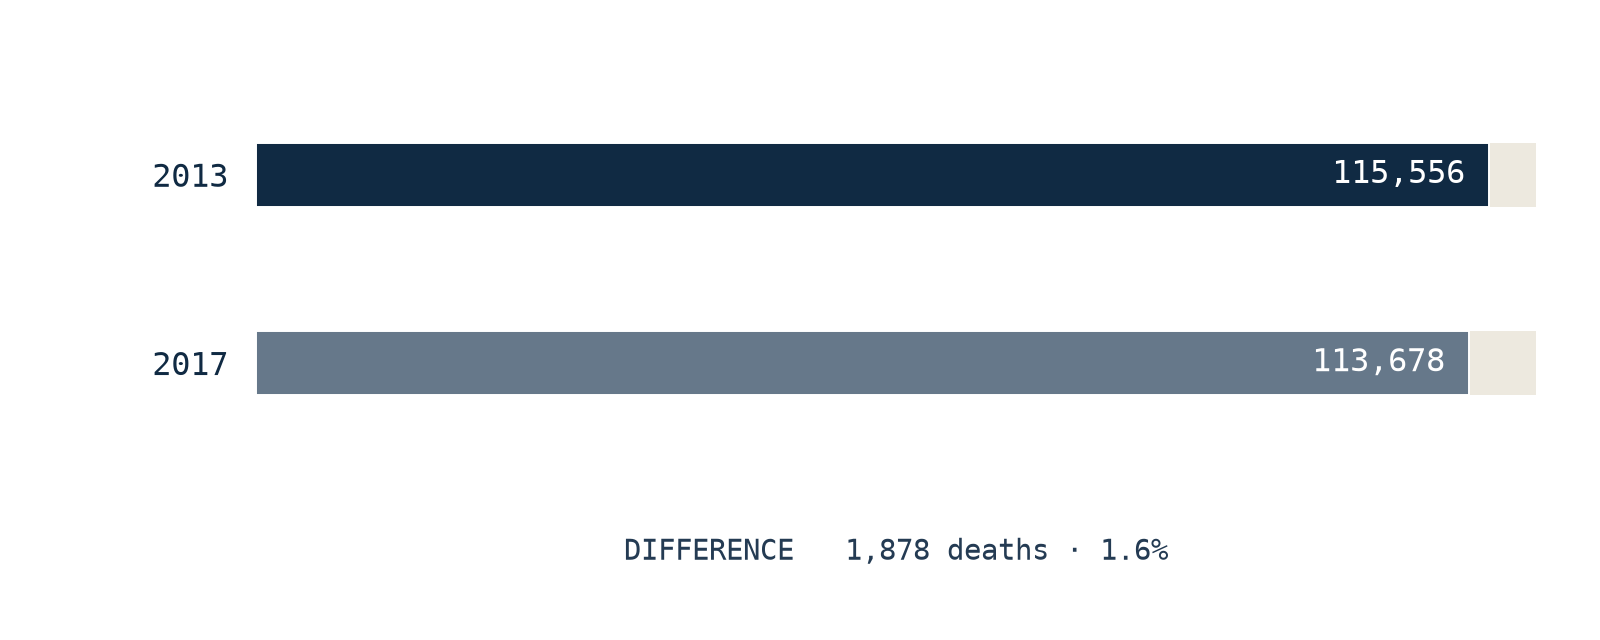

In [7]:
# FIG. 00 — compact opening comparison on a common zero-based scale.
fig00_data = focal.loc[[2013, 2017], ["total"]].reset_index().copy()
fig00_data["difference_from_2013"] = fig00_data["total"] - float(focal.loc[2013, "total"])
opening_gap = int(round(abs(focal.loc[2013, "total"] - focal.loc[2017, "total"])))
opening_gap_pct = opening_gap / max(float(focal.loc[2013, "total"]), float(focal.loc[2017, "total"]))
fig00_values_ok = opening_gap == 1_878 and round(opening_gap_pct * 100, 1) == 1.6

fig, ax = plt.subplots(figsize=FIGURE_PROFILES["opening"]["figsize"])
fig.subplots_adjust(left=0.16, right=0.96, top=0.88, bottom=0.28)
y = np.array([1, 0])
scale_max = 120_000
totals = fig00_data["total"].to_numpy(dtype=float)
ax.barh(y, [scale_max, scale_max], height=0.34, color=COLORS["paper_2"], edgecolor="none", zorder=1)
ax.barh(y, totals, height=0.34, color=[COLORS["ink"], COLORS["muted"]], edgecolor=COLORS["white"], linewidth=0.7, zorder=3)
for y_pos, total in zip(y, totals):
    ax.text(total - 2_200, y_pos, fmt_int(total), ha="right", va="center", color=COLORS["white"], fontsize=11.5, fontfamily=MONO_USED, fontweight="medium", zorder=5)

ax.set_yticks(y, ["2013", "2017"])
ax.set_xlim(0, scale_max)
ax.set_ylim(-0.52, 1.52)
ax.set_xticks([])
ax.tick_params(axis="y", length=0, pad=10, labelcolor=COLORS["ink"], labelsize=11.5)
for label in ax.get_yticklabels():
    label.set_fontfamily(MONO_USED)
ax.spines["bottom"].set_visible(False)
ax.text(0.50, -0.20, f"DIFFERENCE   {fmt_int(opening_gap)} deaths · {opening_gap_pct:.1%}", transform=ax.transAxes, ha="center", va="top", color=COLORS["navy_2"], fontsize=10.5, fontfamily=MONO_USED, fontweight="medium")

fig00_title = "Almost the same annual total"
fig00_caption = f"Worldwide best-estimate totals for 2013 and 2017 on a common zero-based scale: {fmt_int(focal.loc[2013, 'total'])} and {fmt_int(focal.loc[2017, 'total'])}, a difference of {fmt_int(opening_gap)} deaths ({opening_gap_pct:.1%})."
fig00_alt = f"Two horizontal bars on a common zero-based scale. The 2013 total is {fmt_int(focal.loc[2013, 'total'])}; the 2017 total is {fmt_int(focal.loc[2017, 'total'])}. Their difference is {fmt_int(opening_gap)} deaths, or {opening_gap_pct:.1%}."
fig00_paths = export_publication_figure(
    fig,
    output_dir=FIGURE_DIR,
    validation_dir=VALIDATION_DIR,
    stem="fig00_nearly_equal_annual_totals",
    data=fig00_data,
    profile="opening",
    fonts=FONTS,
    metadata={
        "figure_id": "fig00",
        "title": fig00_title,
        "article_slug": ARTICLE_SLUG,
        "caption": fig00_caption,
        "alt_text": fig00_alt,
        "source": "UCDP Organized Violence v26.1; ConflictLens calculations.",
        "measure": "Worldwide annual recorded deaths, best estimate",
        "universe": UNIVERSE,
        "guard": GUARD,
        "period": "2013 and 2017",
        "notebook": f"notebooks/articles/{NOTEBOOK_NAME}",
        "source_commit": SOURCE_COMMIT,
        "x_scale": "linear; common zero baseline; ceiling 120,000",
        "notes": "Opening figure communicates near-equality of volume only; concentration is deliberately withheld for the later structural comparison.",
    },
)
plt.close(fig)
display(Image.open(fig00_paths["png"]))

findfont: Failed to find font weight medium, now using 400.
findfont: Failed to find font weight medium, now using 400.
findfont: Failed to find font weight medium, now using 400.


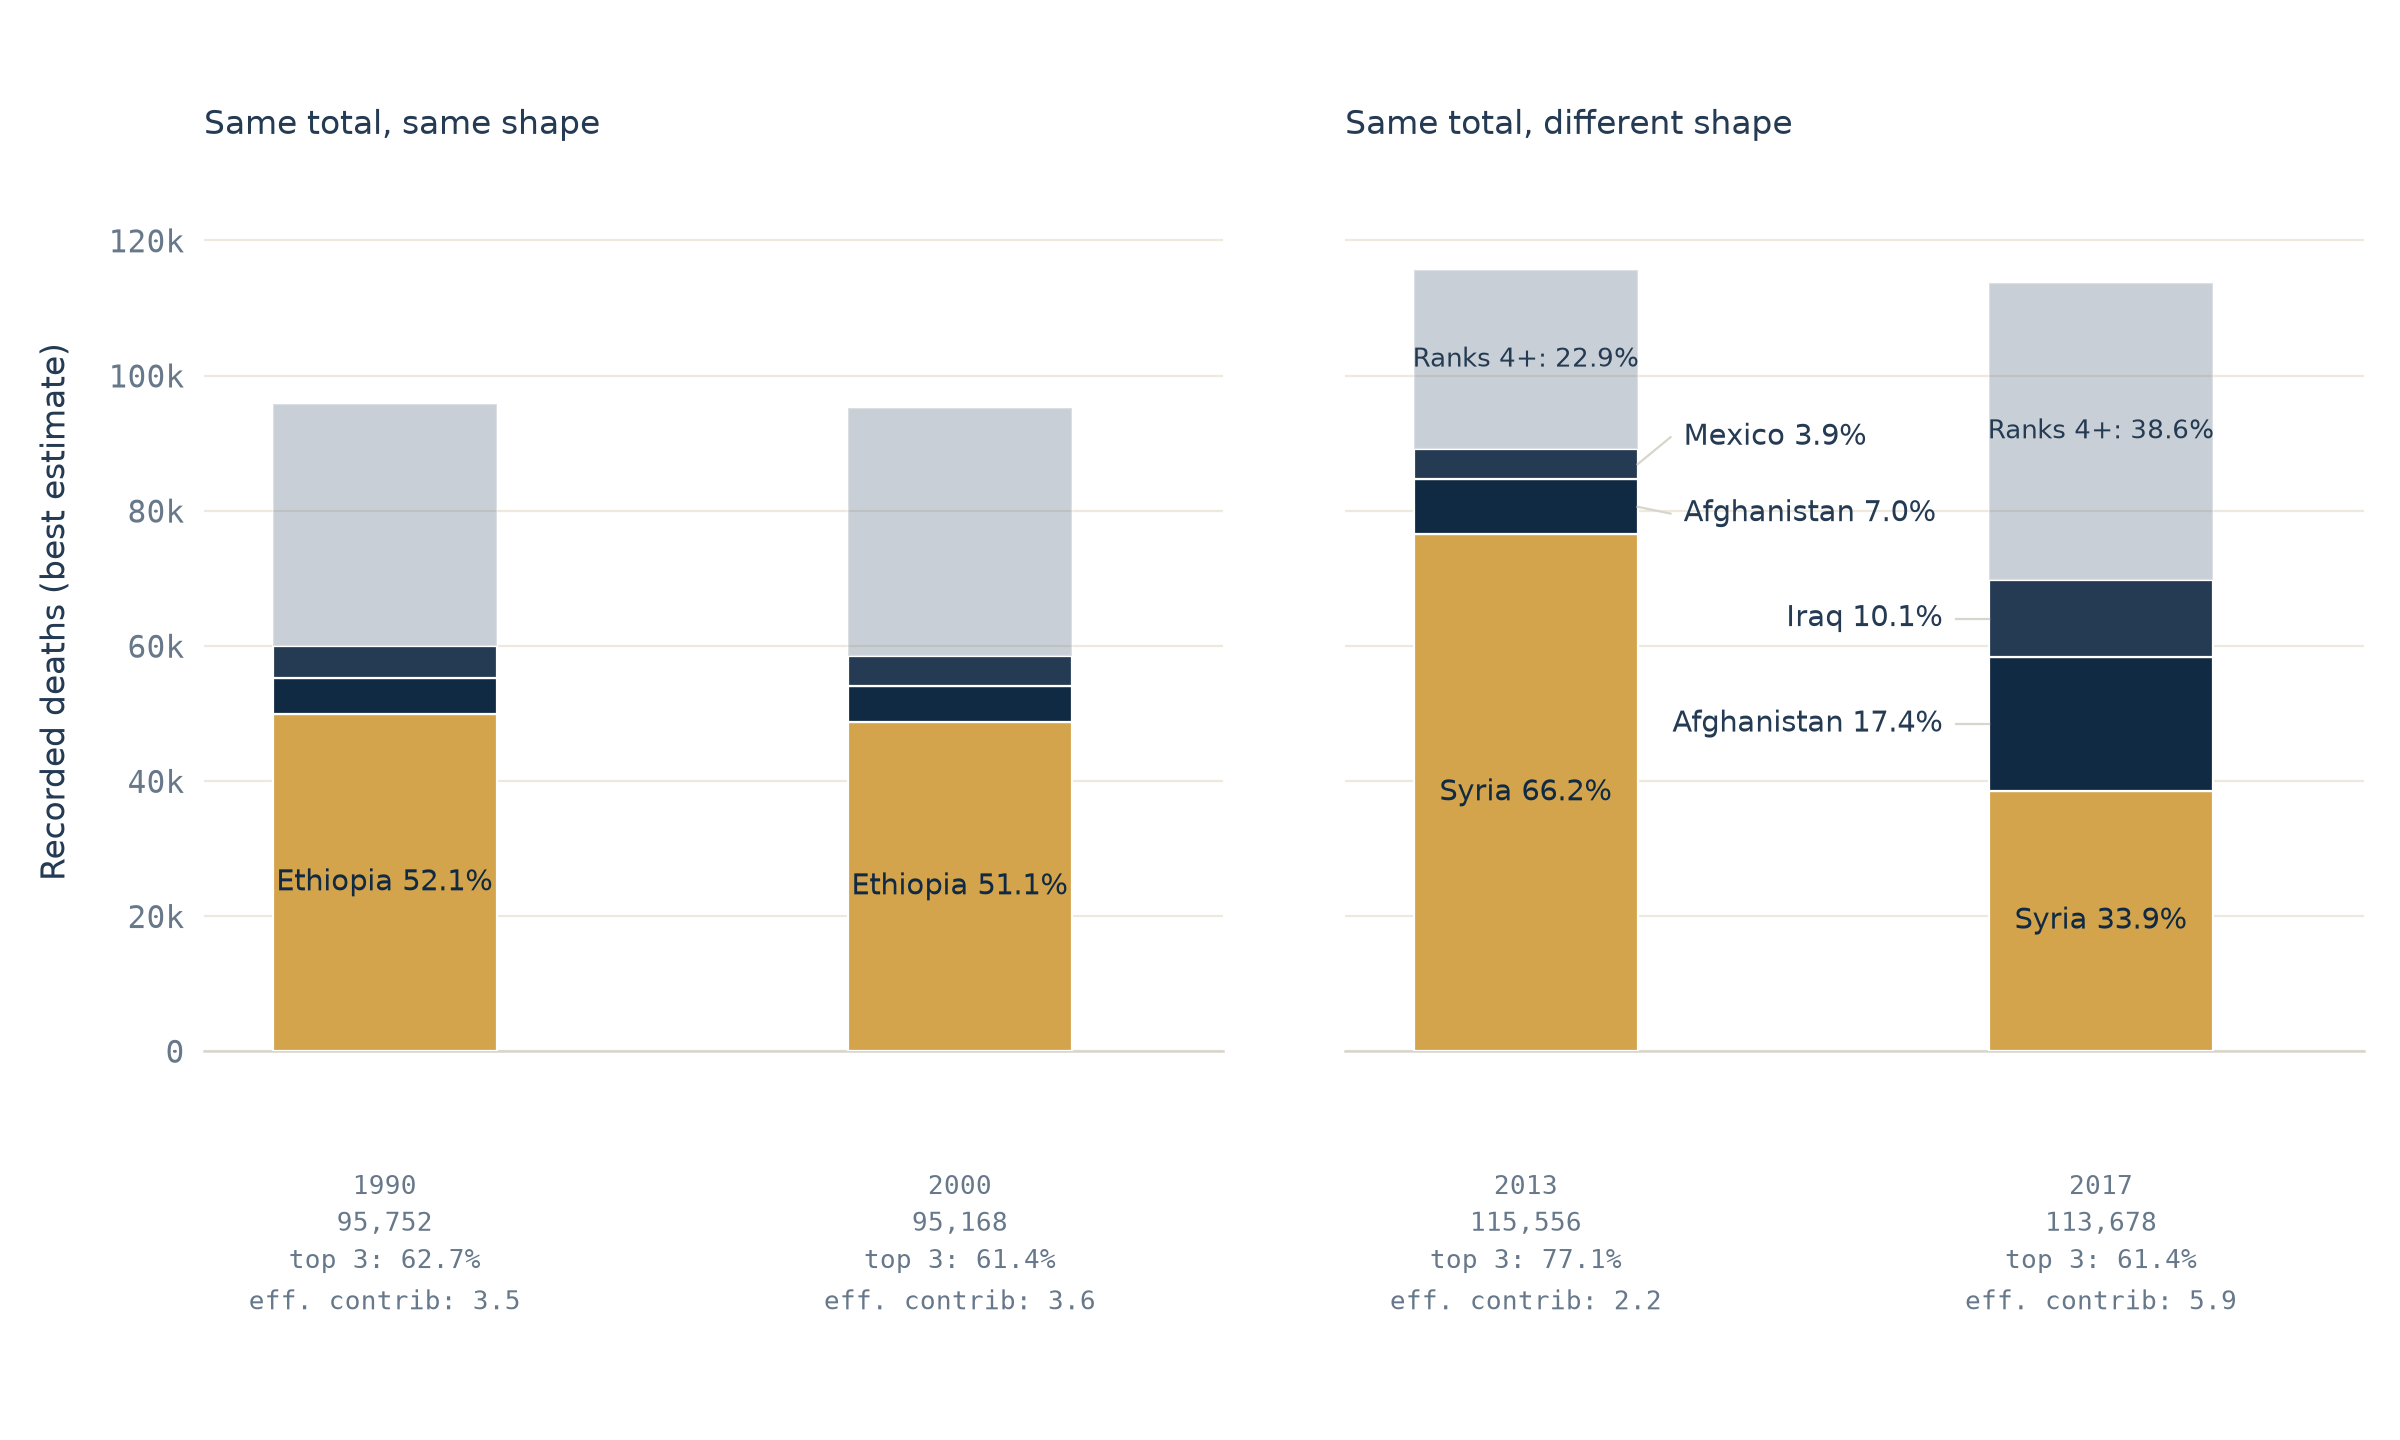

In [8]:
# Long-format data for FIG. 01. Colour encodes rank, never country.
fig01_rows: list[dict[str, object]] = []
panel_map = {1990: "Same total, same shape", 2000: "Same total, same shape", 2013: "Same total, different shape", 2017: "Same total, different shape"}
for year in focal_years:
    row = focal.loc[year]
    segments = [
        ("1st contributor", row["top1_id"], article_label(row["top1_id"], row["top1_label"]), row["top1"], row["s1"]),
        ("2nd contributor", row["top2_id"], article_label(row["top2_id"], row["top2_label"]), row["top2"], row["s2"]),
        ("3rd contributor", row["top3_id"], article_label(row["top3_id"], row["top3_label"]), row["top3"], row["s3"]),
        ("All remaining positive units", "REST", "All remaining positive units", row["rest3"], row["rest3_share"]),
    ]
    for segment_order, (segment, contributor_id, contributor_label, value, share) in enumerate(segments, start=1):
        fig01_rows.append({
            "panel": panel_map[year],
            "year": year,
            "segment_order": segment_order,
            "segment": segment,
            "contributor_id": contributor_id,
            "contributor_label": contributor_label,
            "value": float(value),
            "share": float(share),
            "annual_total": float(row["total"]),
        })
fig01_data = pd.DataFrame(fig01_rows)

fig, axes = plt.subplots(1, 2, figsize=FIGURE_PROFILES["wide"]["figsize"], sharey=True)
fig.subplots_adjust(left=0.085, right=0.985, top=0.88, bottom=0.27, wspace=0.12)
bar_positions = {1990: 0.0, 2000: 1.75, 2013: 0.0, 2017: 1.75}
bar_width = 0.68
y_ceiling = int(math.ceil((float(focal["total"].max()) * 1.10) / 10_000) * 10_000)
segment_styles = {
    "1st contributor": {"color": COLORS["copper"], "alpha": 1.0},
    "2nd contributor": {"color": COLORS["ink"], "alpha": 1.0},
    "3rd contributor": {"color": COLORS["navy_2"], "alpha": 1.0},
    "All remaining positive units": {"color": COLORS["muted"], "alpha": 0.35},
}

for ax, years, panel_title in zip(
    axes,
    [(1990, 2000), (2013, 2017)],
    ["Same total, same shape", "Same total, different shape"],
):
    for year in years:
        row = focal.loc[year]
        x_pos = bar_positions[year]
        bottom = 0.0
        for segment, value in [
            ("1st contributor", float(row["top1"])),
            ("2nd contributor", float(row["top2"])),
            ("3rd contributor", float(row["top3"])),
            ("All remaining positive units", float(row["rest3"])),
        ]:
            style = segment_styles[segment]
            ax.bar(
                x_pos,
                value,
                width=bar_width,
                bottom=bottom,
                color=style["color"],
                alpha=style["alpha"],
                edgecolor=COLORS["white"],
                linewidth=0.8,
                zorder=3,
            )
            bottom += value

        top1_text = f"{article_label(row['top1_id'], row['top1_label'])} {fmt_pct(row['s1'])}"
        ax.text(
            x_pos,
            float(row["top1"]) / 2,
            top1_text,
            ha="center",
            va="center",
            color=COLORS["ink"],
            fontsize=10.5,
            fontfamily=SANS_USED,
            fontweight="medium",
            zorder=5,
        )

        if year in (2013, 2017):
            rest_text = f"Ranks 4+: {fmt_pct(row['rest3_share'])}"
            ax.text(
                x_pos,
                float(row["top3_total"] + row["rest3"] / 2),
                rest_text,
                ha="center",
                va="center",
                color=COLORS["navy_2"],
                fontsize=9.5,
                fontfamily=SANS_USED,
                fontweight="medium",
                zorder=5,
            )

        if year in (2013, 2017):
            rank2_mid = float(row["top1"] + row["top2"] / 2)
            rank3_mid = float(row["top1"] + row["top2"] + row["top3"] / 2)
            rank2_text = f"{article_label(row['top2_id'], row['top2_label'])} {fmt_pct(row['s2'])}"
            rank3_text = f"{article_label(row['top3_id'], row['top3_label'])} {fmt_pct(row['s3'])}"
            if year == 2013:
                rank_label_x = x_pos + 0.48
                rank_label_ha = "left"
                connector_start_x = x_pos + bar_width / 2
                connector_end_x = rank_label_x - 0.04
                rank2_label_y = rank2_mid - 1_000
                rank3_label_y = rank3_mid + 4_000
            else:
                rank_label_x = x_pos - 0.48
                rank_label_ha = "right"
                connector_start_x = x_pos - bar_width / 2
                connector_end_x = rank_label_x + 0.04
                rank2_label_y = rank2_mid
                rank3_label_y = rank3_mid
            for anchor_y, label_y, label_text in [
                (rank2_mid, rank2_label_y, rank2_text),
                (rank3_mid, rank3_label_y, rank3_text),
            ]:
                ax.plot([connector_start_x, connector_end_x], [anchor_y, label_y], color=COLORS["border"], linewidth=0.8, zorder=4)
                ax.text(
                    rank_label_x,
                    label_y,
                    label_text,
                    ha=rank_label_ha,
                    va="center",
                    color=COLORS["navy_2"],
                    fontsize=10.5,
                    fontfamily=SANS_USED,
                    zorder=5,
                )
        stat_text = "\n".join([
            str(year),
            fmt_int(row["total"]),
            f"top 3: {fmt_pct(row['top3_share'])}",
            f"eff. contrib: {row['eff_contrib']:.1f}",
        ])
        ax.text(
            x_pos,
            -0.13,
            stat_text,
            transform=ax.get_xaxis_transform(),
            ha="center",
            va="top",
            color=COLORS["muted"],
            fontsize=9.5,
            fontfamily=MONO_USED,
            linespacing=1.45,
            clip_on=False,
        )

    ax.set_title(panel_title, loc="left", pad=14, color=COLORS["navy_2"], fontsize=12, fontfamily=SANS_USED, fontweight="medium")
    ax.set_xlim(-0.55, 2.55)
    ax.set_ylim(0, y_ceiling)
    ax.set_xticks([])
    style_axis(ax, grid="y", sans=SANS_USED, mono=MONO_USED)

axes[0].set_ylabel("Recorded deaths (best estimate)", labelpad=13)
axes[0].yaxis.set_major_formatter(FuncFormatter(lambda value, _: "0" if value == 0 else f"{int(value/1000):,}k"))
axes[1].tick_params(axis="y", labelleft=False)
axes[1].spines["left"].set_visible(False)

fig01_title = "Annual totals and their ranked contributors, 1990 · 2000 · 2013 · 2017"
fig01_caption = (
    f"Left: 1990 and 2000, totals {smallest_total_gap['relative_total_gap']:.2%} apart and ranked concentration profiles very similar. "
    f"Right: 2013 and 2017, totals {abs(focal.loc[2013, 'total']-focal.loc[2017, 'total'])/max(focal.loc[2013, 'total'],focal.loc[2017, 'total']):.1%} apart, "
    "the widest concentration contrast among the thirteen pairs below the 3% threshold. Each bar is divided into its first, second and third contributor and all remaining positive units."
)
fig01_alt = (
    f"Four stacked bars on a common absolute scale. 1990 and 2000 have nearly identical totals and are both led by Ethiopia at "
    f"{fmt_pct(focal.loc[1990, 's1'])} and {fmt_pct(focal.loc[2000, 's1'])}. 2013 and 2017 have nearly identical totals, but Syria's leading share falls "
    f"from {fmt_pct(focal.loc[2013, 's1'])} to {fmt_pct(focal.loc[2017, 's1'])}."
)
fig01_paths = export_publication_figure(
    fig,
    output_dir=FIGURE_DIR,
    validation_dir=VALIDATION_DIR,
    stem="fig01_paired_ranked_contribution_stacks",
    data=fig01_data,
    profile="wide",
    fonts=FONTS,
    metadata={
        "figure_id": "fig01",
        "title": fig01_title,
        "article_slug": ARTICLE_SLUG,
        "caption": fig01_caption,
        "alt_text": fig01_alt,
        "source": "UCDP Organized Violence v26.1; ConflictLens calculations.",
        "measure": MEASURE,
        "universe": UNIVERSE,
        "guard": GUARD,
        "period": PERIOD,
        "notebook": f"notebooks/articles/{NOTEBOOK_NAME}",
        "source_commit": SOURCE_COMMIT,
        "categorical_mapping": segment_styles,
        "notes": "Colour encodes rank, never country. Common absolute scale and zero baseline. White separators preserve grayscale reading.",
    },
)
plt.close(fig)
display(Image.open(fig01_paths["png"]))

findfont: Failed to find font weight medium, now using 400.


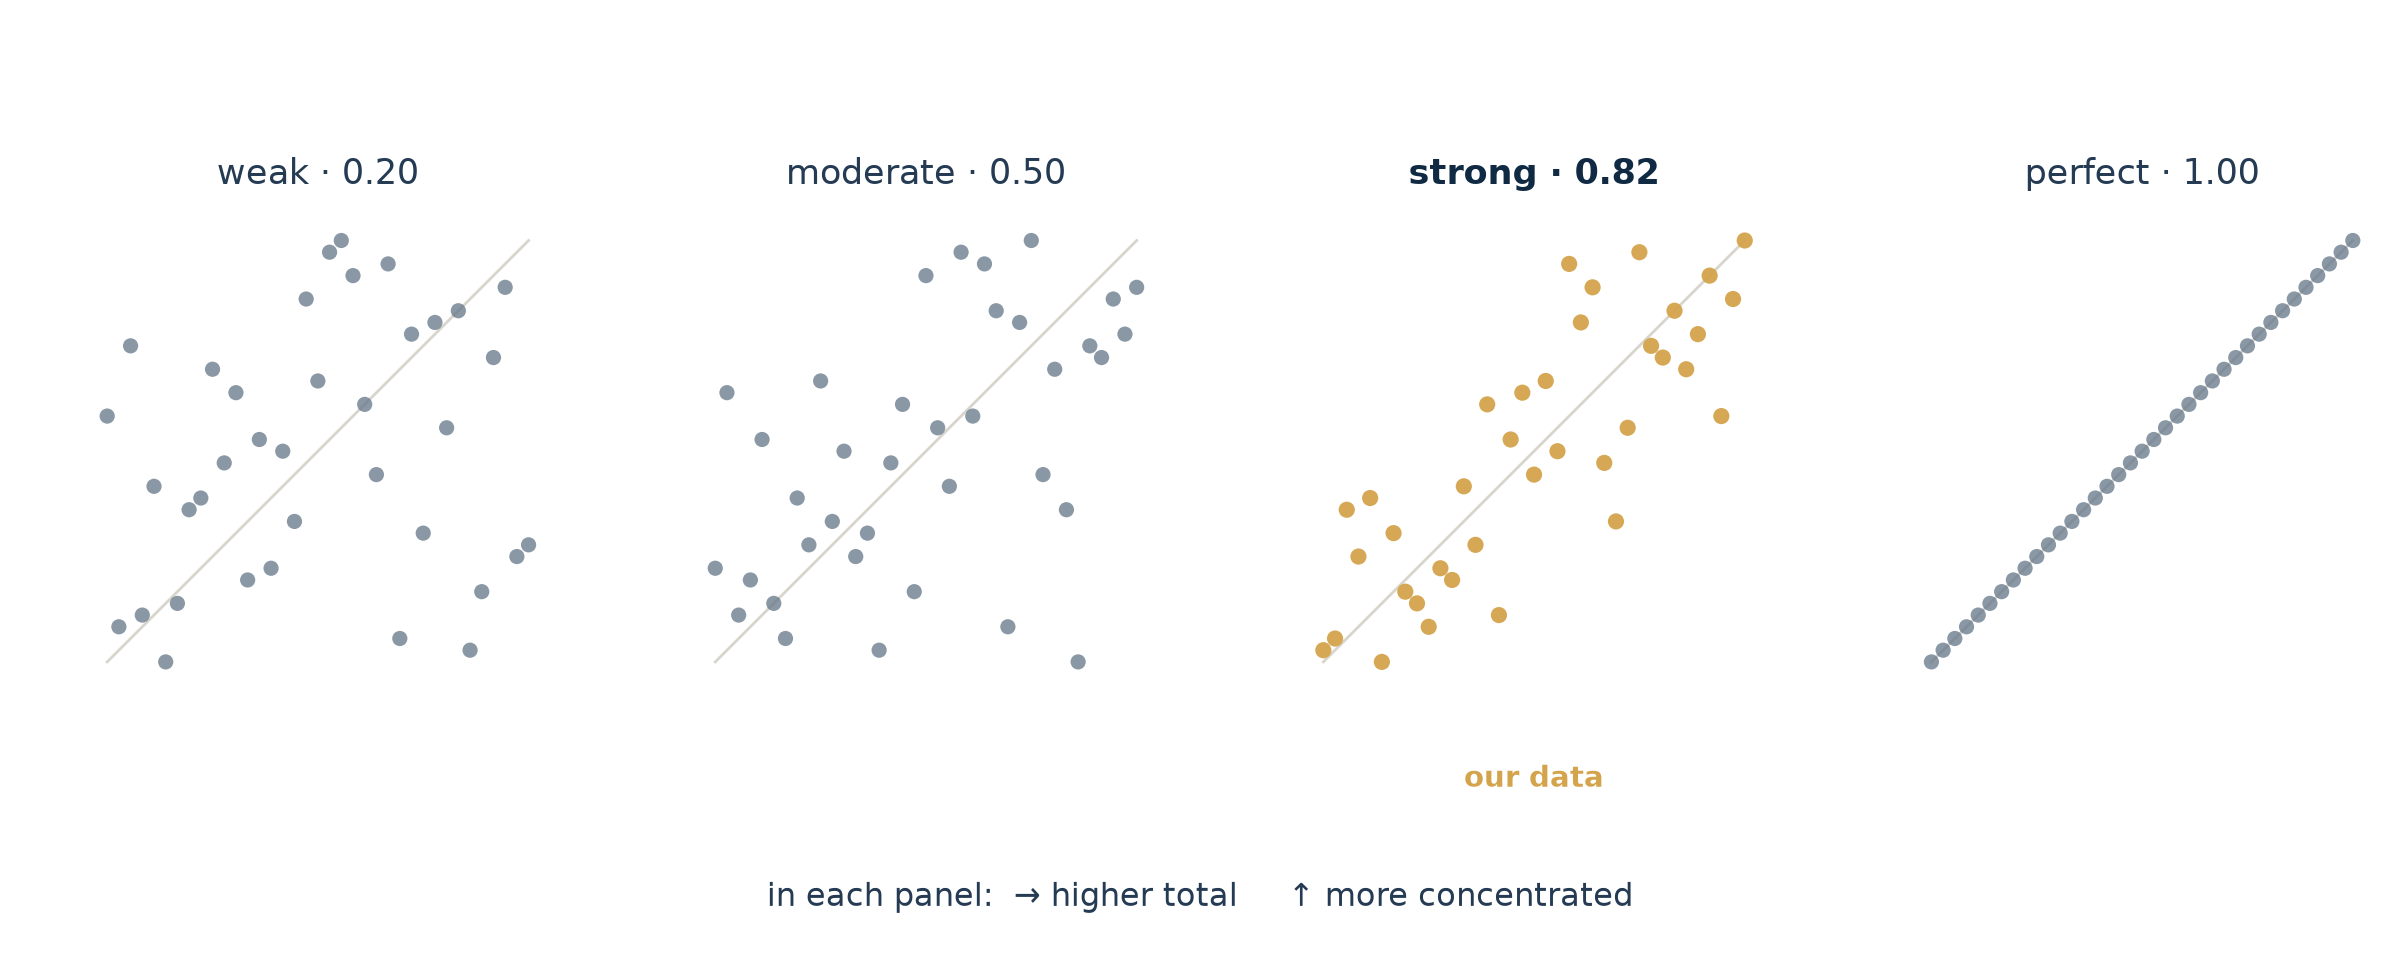

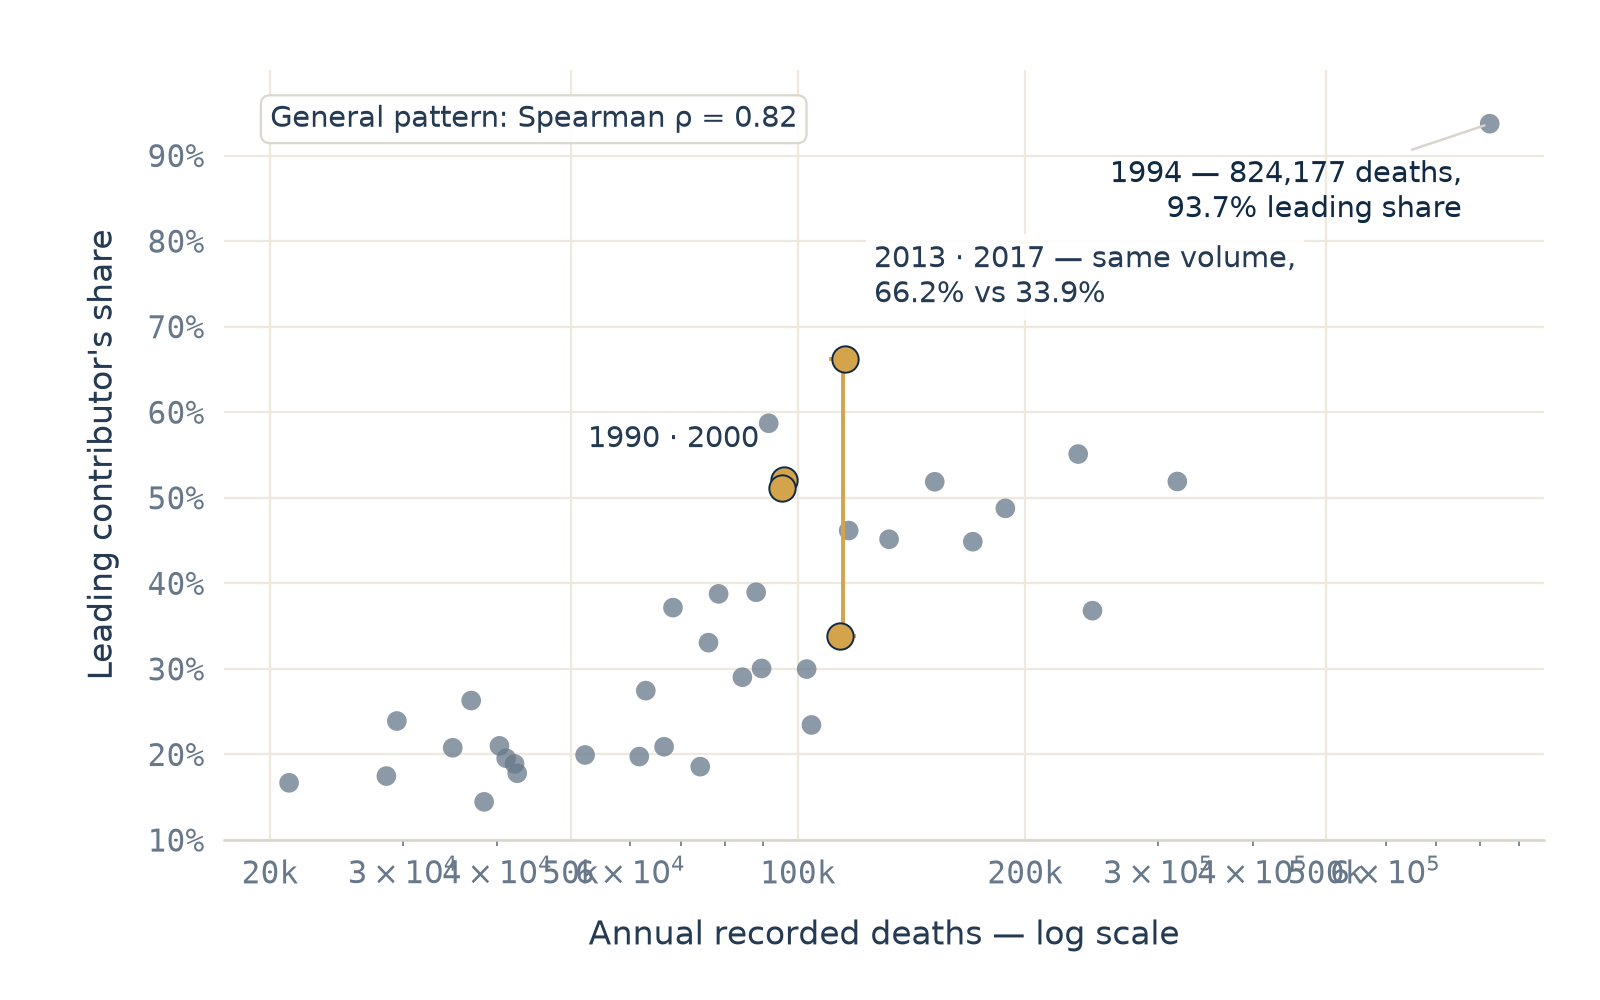

In [9]:
def rank_to_unit_interval(series: pd.Series) -> np.ndarray:
    ranks = series.rank(method="average").to_numpy(dtype=float)
    return (ranks - 1.0) / (len(ranks) - 1.0)


def illustrative_rank_pattern(target: float, seed: int) -> tuple[np.ndarray, np.ndarray, float]:
    """Build a deterministic 37-point rank pattern whose displayed rho rounds to target."""
    x_rank = np.linspace(0.0, 1.0, len(year_structure))
    rng = np.random.default_rng(seed)
    best_y: np.ndarray | None = None
    best_rho = float("nan")
    best_gap = float("inf")
    for _ in range(20_000):
        raw = target * x_rank + math.sqrt(1.0 - target**2) * rng.normal(0.0, np.std(x_rank), len(x_rank))
        y_rank = rank_to_unit_interval(pd.Series(raw))
        rho = pearson_corr(pd.Series(x_rank), pd.Series(y_rank))
        gap = abs(rho - target)
        if gap < best_gap:
            best_y, best_rho, best_gap = y_rank, rho, gap
        if round(rho, 2) == round(target, 2) and gap < 0.0005:
            break
    if best_y is None or round(best_rho, 2) != round(target, 2):
        raise AssertionError(f"Could not generate a deterministic illustrative pattern for rho={target:.2f}.")
    return x_rank, best_y, best_rho


real_x_rank = rank_to_unit_interval(year_structure["total"])
real_y_rank = rank_to_unit_interval(year_structure["s1"])
weak_x, weak_y, weak_rho = illustrative_rank_pattern(0.20, seed=20260717)
moderate_x, moderate_y, moderate_rho = illustrative_rank_pattern(0.50, seed=20260718)
perfect_x = np.linspace(0.0, 1.0, len(year_structure))
perfect_y = perfect_x.copy()
perfect_rho = pearson_corr(pd.Series(perfect_x), pd.Series(perfect_y))
real_rank_rho = pearson_corr(pd.Series(real_x_rank), pd.Series(real_y_rank))

calibration_specs = [
    ("weak", weak_x, weak_y, weak_rho, "illustrative", COLORS["muted"]),
    ("moderate", moderate_x, moderate_y, moderate_rho, "illustrative", COLORS["muted"]),
    ("strong", real_x_rank, real_y_rank, real_rank_rho, "real data", COLORS["copper"]),
    ("perfect", perfect_x, perfect_y, perfect_rho, "illustrative", COLORS["muted"]),
]

calibration_rows: list[dict[str, object]] = []
for label, xs, ys, rho, status, _ in calibration_specs:
    for index, (x_value, y_value) in enumerate(zip(xs, ys)):
        calibration_rows.append({
            "panel": label,
            "point_id": int(year_structure.loc[index, "year"]) if status == "real data" else index + 1,
            "total_rank_0_1": float(x_value),
            "concentration_rank_0_1": float(y_value),
            "spearman_rho": float(rho),
            "data_status": status,
        })
calibration_data = pd.DataFrame(calibration_rows)

FIGURE_PROFILES["calibration"] = {"figsize": (12.0, 4.8), "dpi": 200, "pixels": (2400, 960)}
fig, axes = plt.subplots(1, 4, figsize=FIGURE_PROFILES["calibration"]["figsize"])
fig.subplots_adjust(left=0.035, right=0.99, top=0.82, bottom=0.24, wspace=0.30)

for ax, (label, xs, ys, rho, status, colour) in zip(axes, calibration_specs):
    ax.plot([0, 1], [0, 1], color=COLORS["border"], linewidth=1.0, zorder=1)
    ax.scatter(xs, ys, s=34 if status == "real data" else 30, color=colour, alpha=0.95 if status == "real data" else 0.76, edgecolors="none", zorder=2)
    ax.set_xlim(-0.055, 1.055)
    ax.set_ylim(-0.055, 1.055)
    ax.set_aspect("equal", adjustable="box")
    ax.set_xticks([])
    ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.set_title(
        f"{label} · {rho:.2f}",
        fontsize=12.5,
        fontfamily=SANS_USED,
        fontweight="bold" if status == "real data" else "medium",
        color=COLORS["ink"] if status == "real data" else COLORS["navy_2"],
        pad=12,
    )
    if status == "real data":
        ax.text(0.5, -0.17, "our data", transform=ax.transAxes, ha="center", va="top", fontsize=10.5, fontfamily=SANS_USED, color=COLORS["copper"], fontweight="bold")

fig.text(0.5, 0.065, "in each panel:  → higher total     ↑ more concentrated", ha="center", va="center", fontsize=11.5, fontfamily=SANS_USED, color=COLORS["navy_2"])

calibration_title = "How strong is 0.82? Four patterns of association, from none to perfect."
calibration_caption = (
    "Each dot is a year; the closer the cloud hugs the rising diagonal, the stronger the link. "
    f"Our {len(year_structure)} years sit at {rho_total_s1:.2f} — clearly rising together, with visible exceptions. "
    "The three grey panels are illustrative references; only the amber 0.82 panel is real data."
)
calibration_alt = (
    "Calibration strip with four scatter panels. Each panel plots total rank horizontally and concentration rank vertically. "
    f"The weak reference has rho {weak_rho:.2f}, the moderate reference {moderate_rho:.2f}, the amber real-data panel {real_rank_rho:.2f}, "
    "and the perfect reference 1.00. A rising diagonal marks perfect rank agreement."
)
fig02a_paths = export_publication_figure(
    fig,
    output_dir=FIGURE_DIR,
    validation_dir=VALIDATION_DIR,
    stem="fig02a_association_calibration",
    data=calibration_data,
    profile="calibration",
    fonts=FONTS,
    metadata={
        "figure_id": "fig02a",
        "title": calibration_title,
        "article_slug": ARTICLE_SLUG,
        "caption": calibration_caption,
        "alt_text": calibration_alt,
        "source": "UCDP Organized Violence v26.1 for the amber panel; deterministic ConflictLens illustrations for the grey panels.",
        "measure": "Normalized ranks of annual total and leading-contributor share",
        "universe": UNIVERSE,
        "guard": GUARD,
        "period": PERIOD,
        "notebook": f"notebooks/articles/{NOTEBOOK_NAME}",
        "source_commit": SOURCE_COMMIT,
        "x_scale": "within-panel rank normalized to 0–1",
        "y_scale": "within-panel rank normalized to 0–1",
        "notes": "Spearman correlation is Pearson correlation over ranks. Grey panels are deterministic calibration references with 37 synthetic paired ranks; only the amber panel uses observed yearly ranks.",
    },
)
plt.close(fig)
display(Image.open(fig02a_paths["png"]))

fig02_data = year_structure[["year", "total", "s1", "top1_id", "top1_label", "eff_contrib", "n_positive"]].copy()
fig02_data["top1_article_label"] = [article_label(uid, label) for uid, label in zip(fig02_data["top1_id"], fig02_data["top1_label"])]
fig02_data["focus"] = fig02_data["year"].isin(focal_years)

fig, ax = plt.subplots(figsize=FIGURE_PROFILES["inline"]["figsize"])
fig.subplots_adjust(left=0.14, right=0.965, top=0.93, bottom=0.16)
base = fig02_data.loc[~fig02_data["focus"]]
focus_points = fig02_data.loc[fig02_data["focus"]]
ax.scatter(base["total"], base["s1"], s=50, color=COLORS["muted"], alpha=0.75, edgecolors="none", zorder=2)
ax.scatter(focus_points["total"], focus_points["s1"], s=90, color=COLORS["copper"], edgecolors=COLORS["ink"], linewidths=0.7, zorder=4)

row_1994 = year_structure.loc[year_structure["year"].eq(1994)].iloc[0]
annotation_1994 = f"1994 — {fmt_int(row_1994['total'])} deaths,\n{fmt_pct(row_1994['s1'])} leading share"
ax.annotate(
    annotation_1994,
    xy=(row_1994["total"], row_1994["s1"]),
    xytext=(-10, -12),
    textcoords="offset points",
    ha="right",
    va="top",
    color=COLORS["ink"],
    fontsize=10.5,
    fontfamily=SANS_USED,
    arrowprops={"arrowstyle": "-", "color": COLORS["border"], "linewidth": 0.9},
)

x_pair = math.sqrt(float(focal.loc[2013, "total"] * focal.loc[2017, "total"]))
y_low = float(min(focal.loc[2013, "s1"], focal.loc[2017, "s1"]))
y_high = float(max(focal.loc[2013, "s1"], focal.loc[2017, "s1"]))
cap_ratio = 1.035
ax.plot([x_pair, x_pair], [y_low, y_high], color=COLORS["copper"], linewidth=1.4, zorder=3)
ax.plot([x_pair / cap_ratio, x_pair * cap_ratio], [y_low, y_low], color=COLORS["copper"], linewidth=1.4, zorder=3)
ax.plot([x_pair / cap_ratio, x_pair * cap_ratio], [y_high, y_high], color=COLORS["copper"], linewidth=1.4, zorder=3)
pair_annotation = f"2013 · 2017 — same volume,\n{fmt_pct(focal.loc[2013, 's1'])} vs {fmt_pct(focal.loc[2017, 's1'])}"
ax.text(
    x_pair * 1.10,
    y_high + 0.055,
    pair_annotation,
    ha="left",
    va="bottom",
    color=COLORS["navy_2"],
    fontsize=10.5,
    fontfamily=SANS_USED,
    bbox={"boxstyle": "round,pad=0.28", "facecolor": COLORS["white"], "edgecolor": "none", "alpha": 0.90},
)

x_control = math.sqrt(float(focal.loc[1990, "total"] * focal.loc[2000, "total"]))
y_control = float((focal.loc[1990, "s1"] + focal.loc[2000, "s1"]) / 2)
control_annotation = "1990 · 2000"
ax.text(
    x_control * 0.93,
    y_control + 0.035,
    control_annotation,
    ha="right",
    va="bottom",
    color=COLORS["navy_2"],
    fontsize=10.5,
    fontfamily=SANS_USED,
)

ax.text(
    0.035,
    0.955,
    f"General pattern: Spearman ρ = {rho_total_s1:.2f}",
    transform=ax.transAxes,
    ha="left",
    va="top",
    color=COLORS["navy_2"],
    fontsize=10.5,
    fontfamily=SANS_USED,
    fontweight="medium",
    bbox={"boxstyle": "round,pad=0.32", "facecolor": COLORS["white"], "edgecolor": COLORS["border"], "linewidth": 0.8, "alpha": 0.92},
)

ax.set_xscale("log")
ax.set_xlim(year_structure["total"].min() * 0.82, year_structure["total"].max() * 1.18)
ax.set_ylim(0.10, 1.00)
ax.set_xlabel("Annual recorded deaths — log scale", labelpad=10)
ax.set_ylabel("Leading contributor's share", labelpad=10)
ax.set_yticks(np.arange(0.10, 1.00, 0.10))
ax.yaxis.set_major_formatter(FuncFormatter(lambda value, _: f"{value:.0%}"))
log_ticks = [20_000, 50_000, 100_000, 200_000, 500_000, 1_000_000]
ax.xaxis.set_major_locator(FixedLocator(log_ticks))
ax.xaxis.set_major_formatter(FuncFormatter(lambda value, _: f"{int(value/1000):,}k" if value < 1_000_000 else "1m"))
style_axis(ax, grid="both", sans=SANS_USED, mono=MONO_USED)

fig02_title = "Annual total and leading-contributor share, 1989–2025"
fig02_caption = (
    f"Annual total against leading-contributor share, {START_YEAR}–{END_YEAR}, with a logarithmic horizontal axis. "
    f"The two move together (Spearman ρ = {rho_total_s1:.2f}), but the spread around that tendency is wide. "
    f"1994 sits at {fmt_int(row_1994['total'])} deaths and a {fmt_pct(row_1994['s1'])} leading share."
)
fig02_alt = (
    f"Scatter plot of all {len(year_structure)} years. The cloud slopes upward. 1990 and 2000 nearly overlap. "
    f"2013 and 2017 have similar totals but leading shares of {fmt_pct(focal.loc[2013, 's1'])} and {fmt_pct(focal.loc[2017, 's1'])}."
)
fig02_paths = export_publication_figure(
    fig,
    output_dir=FIGURE_DIR,
    validation_dir=VALIDATION_DIR,
    stem="fig02_annual_total_vs_leading_share",
    data=fig02_data,
    profile="inline",
    fonts=FONTS,
    metadata={
        "figure_id": "fig02",
        "title": fig02_title,
        "article_slug": ARTICLE_SLUG,
        "caption": fig02_caption,
        "alt_text": fig02_alt,
        "source": "UCDP Organized Violence v26.1; ConflictLens calculations.",
        "measure": "Annual total and rank-1 contributor share",
        "universe": UNIVERSE,
        "guard": GUARD,
        "period": PERIOD,
        "notebook": f"notebooks/articles/{NOTEBOOK_NAME}",
        "source_commit": SOURCE_COMMIT,
        "x_scale": "logarithmic; full-period range is ×38.9 and 1994 is retained",
        "notes": "No fitted line: the correlation is reported in the caption to avoid causal framing.",
    },
)
plt.close(fig)
display(Image.open(fig02_paths["png"]))

findfont: Failed to find font weight medium, now using 400.
findfont: Failed to find font weight medium, now using 400.


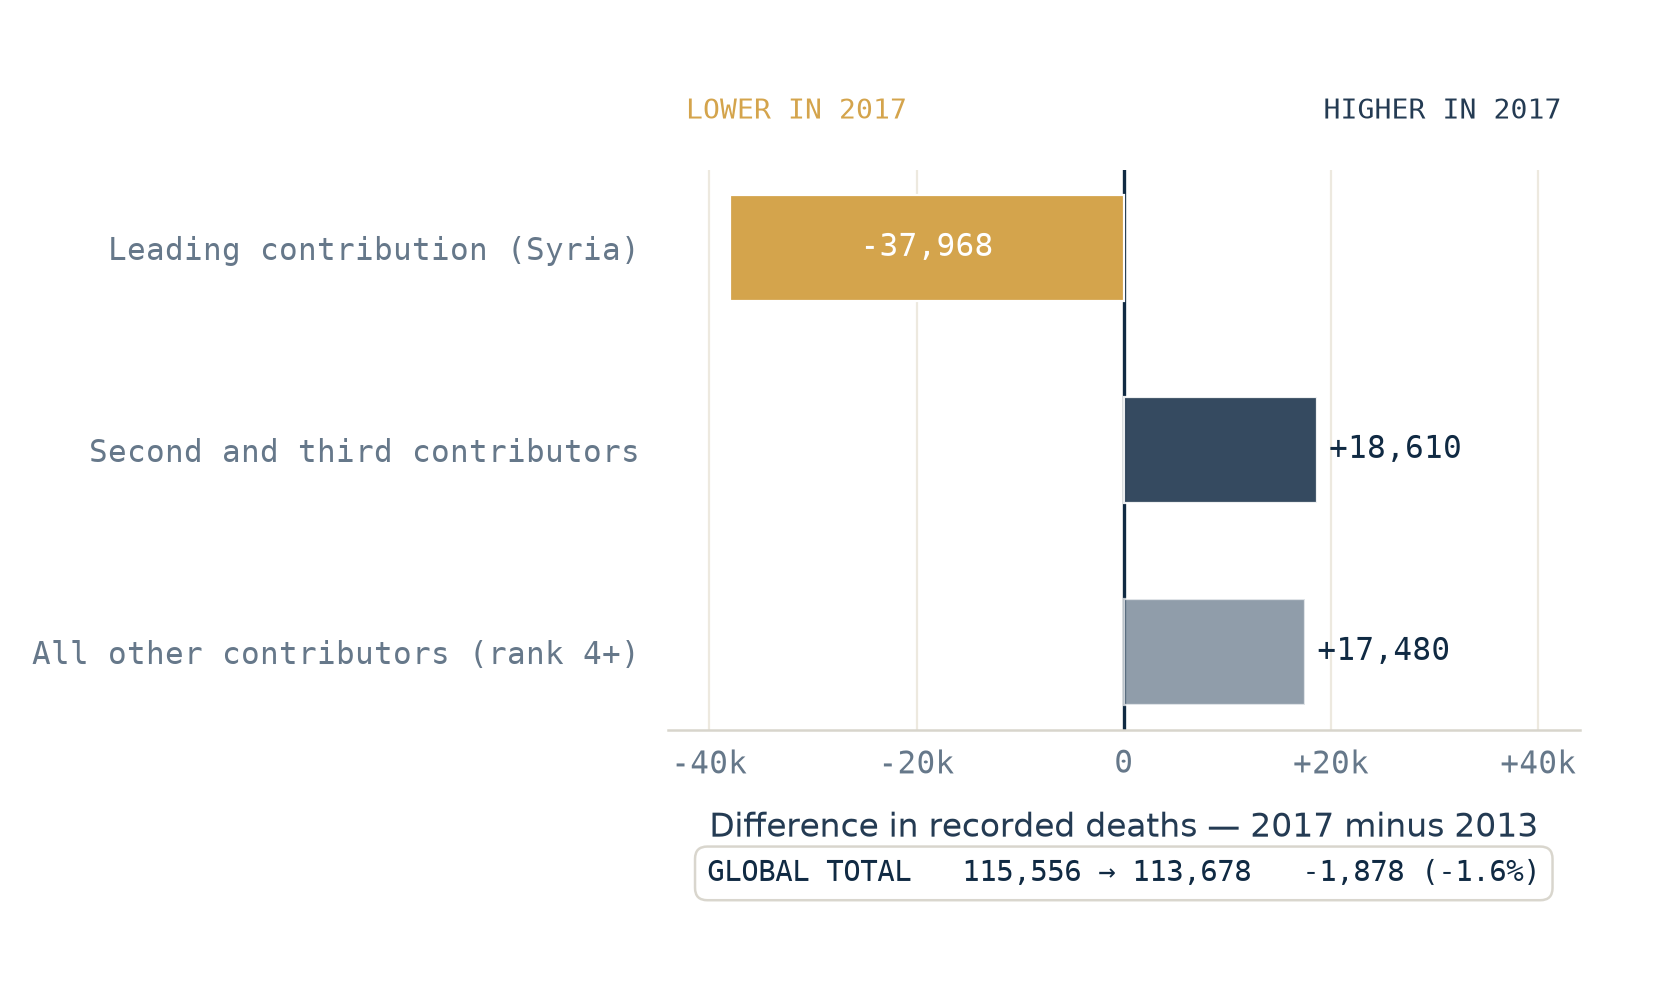

In [10]:
# FIG. 03 — differences between the 2017 and 2013 endpoints, centred on zero.
start_total = int(round(focal.loc[2013, 'total']))
end_total = int(round(focal.loc[2017, 'total']))
positive_offset = delta_top23 + delta_rest3
fig03_balance_ok = delta_top1 + positive_offset == delta_total
fig03_data = pd.DataFrame([
    {"component_order": 1, "component": "Leading contribution (Syria)", "value": delta_top1, "display": "bar"},
    {"component_order": 2, "component": "Second and third contributors", "value": delta_top23, "display": "bar"},
    {"component_order": 3, "component": "All other contributors (rank 4+)", "value": delta_rest3, "display": "bar"},
    {"component_order": 4, "component": "Global total", "value": delta_total, "display": "summary"},
])

plot_data = fig03_data.loc[fig03_data["display"].eq("bar")].copy()
y = np.arange(len(plot_data))[::-1]
values = plot_data["value"].to_numpy(dtype=float)
bar_colors = [COLORS["copper"], COLORS["navy_2"], COLORS["muted"]]
bar_alphas = [1.0, 0.92, 0.72]

fig, ax = plt.subplots(figsize=FIGURE_PROFILES["inline"]["figsize"])
fig.subplots_adjust(left=0.38, right=0.95, top=0.83, bottom=0.27)
for y_pos, value, color, alpha in zip(y, values, bar_colors, bar_alphas):
    ax.barh(y_pos, value, height=0.52, color=color, alpha=alpha, edgecolor=COLORS["white"], linewidth=0.8, zorder=3)
    label_x = value / 2 if value < 0 else value + 1_200
    label_ha = "center" if value < 0 else "left"
    label_color = COLORS["white"] if value < 0 else COLORS["ink"]
    ax.text(label_x, y_pos, f"{int(value):+,}", ha=label_ha, va="center", color=label_color, fontsize=11, fontfamily=MONO_USED, fontweight="medium", zorder=5)

axis_limit = 44_000
ax.axvline(0, color=COLORS["ink"], linewidth=1.2, zorder=2)
ax.set_xlim(-axis_limit, axis_limit)
ax.set_yticks(y, plot_data["component"].tolist())
ax.set_xlabel("Difference in recorded deaths — 2017 minus 2013", labelpad=11)
ax.xaxis.set_major_locator(FixedLocator([-40_000, -20_000, 0, 20_000, 40_000]))
ax.xaxis.set_major_formatter(FuncFormatter(lambda value, _: "0" if value == 0 else f"{value/1000:+.0f}k"))
style_axis(ax, grid="x", sans=SANS_USED, mono=MONO_USED)
ax.spines["left"].set_visible(False)
ax.tick_params(axis="y", length=0, pad=10)

ax.text(0.02, 1.08, "LOWER IN 2017", transform=ax.transAxes, ha="left", va="bottom", color=COLORS["copper"], fontsize=10, fontfamily=MONO_USED, fontweight="medium")
ax.text(0.98, 1.08, "HIGHER IN 2017", transform=ax.transAxes, ha="right", va="bottom", color=COLORS["navy_2"], fontsize=10, fontfamily=MONO_USED, fontweight="medium")
summary_text = f"GLOBAL TOTAL   {fmt_int(start_total)} → {fmt_int(end_total)}   {delta_total:+,} ({delta_total/start_total:+.1%})"
ax.text(0.50, -0.23, summary_text, transform=ax.transAxes, ha="center", va="top", color=COLORS["ink"], fontsize=10.5, fontfamily=MONO_USED, fontweight="medium", bbox={"boxstyle": "round,pad=0.42", "facecolor": COLORS["white"], "edgecolor": COLORS["border"], "linewidth": 0.9, "alpha": 0.96})

fig03_title = "One large fall, two offsetting increases"
fig03_caption = (
    f"Difference in recorded deaths between the 2017 and 2013 best-estimate endpoints. The leading contribution is {fmt_int(abs(delta_top1))} lower in 2017; "
    f"the other two ranked components are {fmt_int(positive_offset)} higher together, leaving the global total {fmt_int(abs(delta_total))} lower. "
    "The bars compare two endpoint distributions; they do not represent flows."
)
fig03_alt = (
    f"Diverging horizontal bars centred on zero. The leading contribution is {abs(delta_top1):,} lower in 2017, while the second and third contributors are {delta_top23:,} higher and contributors ranked fourth or lower are {delta_rest3:,} higher. "
    f"The global total changes from {start_total:,} to {end_total:,}, a difference of {delta_total:+,}."
)
fig03_paths = export_publication_figure(
    fig,
    output_dir=FIGURE_DIR,
    validation_dir=VALIDATION_DIR,
    stem="fig03_endpoint_difference_diverging_bars",
    data=fig03_data,
    profile="inline",
    fonts=FONTS,
    metadata={
        "figure_id": "fig03",
        "title": fig03_title,
        "article_slug": ARTICLE_SLUG,
        "caption": fig03_caption,
        "alt_text": fig03_alt,
        "source": "UCDP Organized Violence v26.1; ConflictLens calculations.",
        "measure": "2017 minus 2013 endpoint difference by ranked component",
        "universe": UNIVERSE,
        "guard": GUARD,
        "period": "2013 and 2017 endpoints",
        "notebook": f"notebooks/articles/{NOTEBOOK_NAME}",
        "source_commit": SOURCE_COMMIT,
        "notes": "Zero-centred endpoint differences. Negative means lower in 2017; positive means higher in 2017. Bars must not be interpreted as temporal flows or stable geographic groups.",
    },
)
plt.close(fig)
display(Image.open(fig03_paths["png"]))

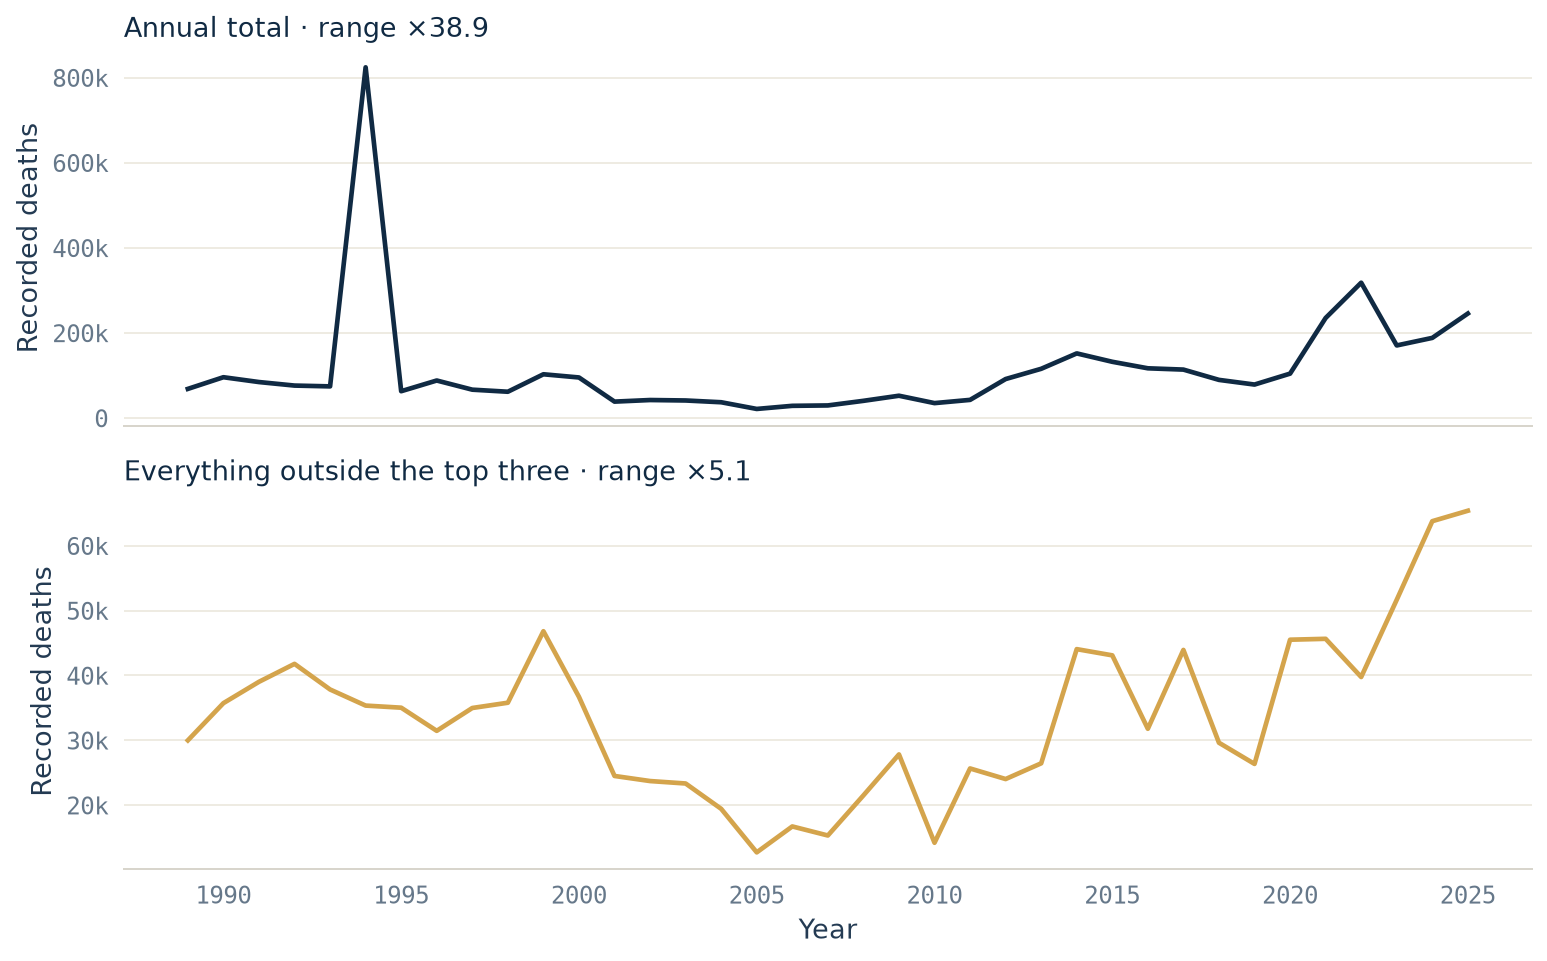

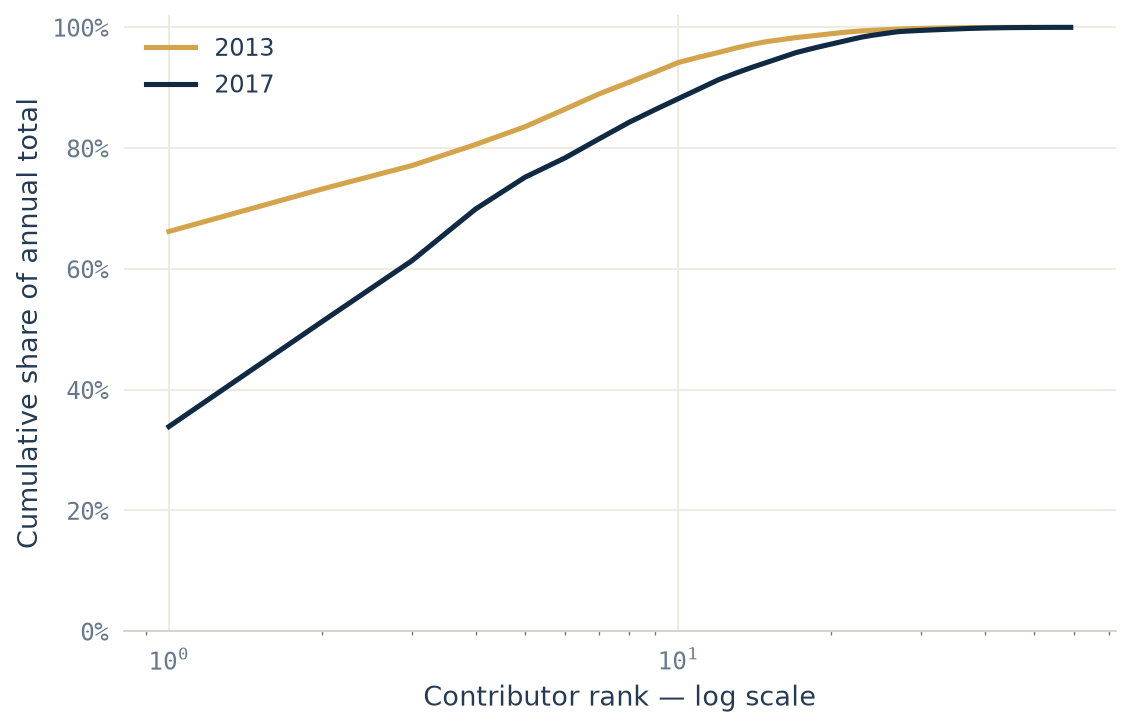

In [11]:
# Notebook-only control 1: total versus the rank-four-and-below component.
control01_path = VALIDATION_DIR / "control_total_vs_rest3.png"
fig, axes = plt.subplots(2, 1, figsize=(10, 6.4), sharex=True)
fig.subplots_adjust(left=0.10, right=0.98, top=0.91, bottom=0.11, hspace=0.18)
axes[0].plot(year_structure["year"], year_structure["total"], color=COLORS["ink"], linewidth=2.1)
axes[1].plot(year_structure["year"], year_structure["rest3"], color=COLORS["copper"], linewidth=2.1)
axes[0].set_title(f"Annual total · range ×{total_desc['range_ratio']:.1f}", loc="left", fontsize=12)
axes[1].set_title(f"Everything outside the top three · range ×{rest_desc['range_ratio']:.1f}", loc="left", fontsize=12)
for ax in axes:
    ax.set_ylabel("Recorded deaths")
    ax.yaxis.set_major_formatter(FuncFormatter(lambda value, _: "0" if value == 0 else f"{int(value/1000):,}k"))
    style_axis(ax, grid="y", sans=SANS_USED, mono=MONO_USED)
axes[1].set_xlabel("Year")
fig.savefig(control01_path, dpi=160, bbox_inches="tight", facecolor=COLORS["white"], transparent=False)
plt.close(fig)

# Notebook-only control 2: cumulative share by rank for 2013 and 2017.
control02_path = VALIDATION_DIR / "control_cumulative_share_by_rank_2013_2017.png"
fig, ax = plt.subplots(figsize=(8, 5))
for year, color in [(2013, COLORS["copper"]), (2017, COLORS["ink"])]:
    positive = frame.loc[(frame["year"].eq(year)) & frame[MEASURE].gt(0)].sort_values(MEASURE, ascending=False)
    curve = positive[MEASURE].cumsum() / positive[MEASURE].sum()
    ax.plot(np.arange(1, len(curve) + 1), curve, linewidth=2.3, color=color, label=str(year))
ax.set_xscale("log")
ax.set_ylim(0, 1.02)
ax.set_xlabel("Contributor rank — log scale")
ax.set_ylabel("Cumulative share of annual total")
ax.yaxis.set_major_formatter(FuncFormatter(lambda value, _: f"{value:.0%}"))
style_axis(ax, grid="both", sans=SANS_USED, mono=MONO_USED)
ax.legend(frameon=False)
fig.savefig(control02_path, dpi=160, bbox_inches="tight", facecolor=COLORS["white"], transparent=False)
plt.close(fig)

display_note(
    "Controls retained, not published",
    "The total-versus-remainder control shows that the rank-four-and-below component varies much less than the aggregate. Its membership changes by year. "
    "The cumulative-rank control confirms that the 2013–2017 difference is not an artefact of cutting at rank three.",
    kind="info",
)
display(Image.open(control01_path))
display(Image.open(control02_path))

In [12]:
# A23 — exported figure data reconcile with asserted focal-year totals.
fig00_exported = pd.read_csv(fig00_paths["data"]).set_index("year")
fig01_exported = pd.read_csv(fig01_paths["data"])
fig01_sums = fig01_exported.groupby("year", as_index=True)["value"].sum()
fig02_exported = pd.read_csv(fig02_paths["data"]).set_index("year")
fig03_exported = pd.read_csv(fig03_paths["data"])
fig_data_ok = True
fig_data_details: list[str] = []
for year in focal_years:
    expected_total = float(focal.loc[year, "total"])
    observed_stack = float(fig01_sums.loc[year])
    observed_scatter = float(fig02_exported.loc[year, "total"])
    observed_opening = float(fig00_exported.loc[year, "total"]) if year in (2013, 2017) else expected_total
    year_ok = observed_stack == expected_total and observed_scatter == expected_total and observed_opening == expected_total
    fig_data_ok = fig_data_ok and year_ok
    fig_data_details.append(f"{year}: opening={observed_opening:.0f}, stack={observed_stack:.0f}, scatter={observed_scatter:.0f}, expected={expected_total:.0f}")
record_check("A23", fig_data_ok, "; ".join(fig_data_details))

figure_manifest = pd.DataFrame([
    {"figure": "fig00", **{kind: str(path.relative_to(PROJECT_ROOT)) for kind, path in fig00_paths.items()}},
    {"figure": "fig01", **{kind: str(path.relative_to(PROJECT_ROOT)) for kind, path in fig01_paths.items()}},
    {"figure": "fig02", **{kind: str(path.relative_to(PROJECT_ROOT)) for kind, path in fig02_paths.items()}},
    {"figure": "fig03", **{kind: str(path.relative_to(PROJECT_ROOT)) for kind, path in fig03_paths.items()}},
])
display(figure_manifest)

,figure,png,svg,data,metadata,preview
0,fig00,figures/two-years-almost-the-same-toll/fig00_nearly_equal_annual_totals.png,figures/two-years-almost-the-same-toll/fig00_nearly_equal_annual_totals.svg,figures/two-years-almost-the-same-toll/fig00_nearly_equal_annual_totals_data.csv,figures/two-years-almost-the-same-toll/fig00_nearly_equal_annual_totals_metadata.json,figures/two-years-almost-the-same-toll/validation/fig00_nearly_equal_annual_totals_360px.png
1,fig01,figures/two-years-almost-the-same-toll/fig01_paired_ranked_contribution_stacks.png,figures/two-years-almost-the-same-toll/fig01_paired_ranked_contribution_stacks.svg,figures/two-years-almost-the-same-toll/fig01_paired_ranked_contribution_stacks_data.csv,figures/two-years-almost-the-same-toll/fig01_paired_ranked_contribution_stacks_metadata.json,figures/two-years-almost-the-same-toll/validation/fig01_paired_ranked_contribution_stacks_360px.png
2,fig02,figures/two-years-almost-the-same-toll/fig02_annual_total_vs_leading_share.png,figures/two-years-almost-the-same-toll/fig02_annual_total_vs_leading_share.svg,figures/two-years-almost-the-same-toll/fig02_annual_total_vs_leading_share_data.csv,figures/two-years-almost-the-same-toll/fig02_annual_total_vs_leading_share_metadata.json,figures/two-years-almost-the-same-toll/validation/fig02_annual_total_vs_leading_share_360px.png
3,fig03,figures/two-years-almost-the-same-toll/fig03_endpoint_difference_diverging_bars.png,figures/two-years-almost-the-same-toll/fig03_endpoint_difference_diverging_bars.svg,figures/two-years-almost-the-same-toll/fig03_endpoint_difference_diverging_bars_data.csv,figures/two-years-almost-the-same-toll/fig03_endpoint_difference_diverging_bars_metadata.json,figures/two-years-almost-the-same-toll/validation/fig03_endpoint_difference_diverging_bars_360px.png


<a id="validation"></a>

## 07 — Validation summary

**Question.** Can a reviewer trace every article-facing value and every exported artefact to an executed assertion?  
**Method.** Build a structured value registry, include all numeric tokens found in the supplied article Markdown for grep-based review, then emit `validation_summary.json`.  
**Contract note.** The export contract now contains five figure metadata files plus `notebook_metadata.json` and `validation_summary.json`.

In [13]:
article_path = PROJECT_ROOT / "articles" / "01b-two-years-almost-the-same-toll.md"
article_text = article_path.read_text(encoding="utf-8") if article_path.exists() else ""
article_numeric_tokens = sorted(set(re.findall(r"(?<![A-Za-z])(?:[+−-]?\d[\d,]*(?:\.\d+)?%?|v\d+\.\d+)", article_text)))

article_facing_values = {
    "period": {"start_year": START_YEAR, "end_year": END_YEAR, "year_count": int(len(year_structure))},
    "panel_relationship": {
        "spearman_total_leading_share": round(rho_total_s1, 6),
        "spearman_total_leading_share_excluding_1994": round(rho_total_s1_ex1994, 6),
        "pearson_total_leading_share": round(pearson_total_s1, 6),
        "pearson_total_leading_share_excluding_1994": round(pearson_total_s1_ex1994, 6),
        "spearman_total_effective_contributors": round(rho_total_eff, 6),
        "spearman_total_positive_units": round(rho_total_n_positive, 6),
        "ols_total_on_top1_excluding_1994_r2": round(ols_r2, 6),
        "top_ten_overlap_count": top_ten_overlap_count,
        "top_ten_overlap_years": top_ten_overlap_years,
        "calibration_coefficients": {
            "weak_illustrative": round(weak_rho, 6),
            "moderate_illustrative": round(moderate_rho, 6),
            "strong_real_data": round(real_rank_rho, 6),
            "perfect_illustrative": round(perfect_rho, 6),
        },
    },
    "descriptives": {
        row["series"]: {
            "min": int(round(row["min"])),
            "median": int(round(row["median"])),
            "max": int(round(row["max"])),
            "range_ratio": round(float(row["range_ratio"]), 3),
            "cv": round(float(row["cv"]), 6),
        }
        for row in descriptives.to_dict("records")
    },
    "pair_selection": {
        "thresholds": [0.02, 0.03, 0.05],
        "pairs_under_3pct": int(len(scan_003)),
        "selected_pair": [2013, 2017],
        "selected_pair_total_gap": round(float(all_pairs_df.loc[(all_pairs_df["year_a"].eq(2013)) & (all_pairs_df["year_b"].eq(2017)), "relative_total_gap"].iloc[0]), 8),
        "selected_pair_leading_share_gap_points": round(float(winning_deltas[0.03] * 100), 3),
        "selected_pair_metric_winners_under_3pct": {metric: list(pair) for metric, pair in concentration_metric_winners_003.items()},
        "selected_pair_hhi_gap": round(float(selected_pair_003["abs_delta_hhi"]), 8),
        "selected_pair_effective_contributor_gap": round(float(selected_pair_003["abs_delta_effective_contributors"]), 8),
        "selected_pair_top3_share_gap_points": round(float(selected_pair_003["abs_delta_top3_share"] * 100), 3),
        "selected_pair_ranked_profile_tv": round(float(selected_pair_003["ranked_profile_tv"]), 8),
        "selected_pair_identity_aligned_tv_rank_under_3pct": selected_unit_tv_rank_003,
        "control_pair": [1990, 2000],
        "control_pair_total_gap": round(float(smallest_total_gap["relative_total_gap"]), 8),
        "control_pair_leading_share_gap_points": round(float(smallest_delta_002["abs_delta_s1"] * 100), 3),
    },
    "focal_years": {
        str(year): {
            "total": int(round(focal.loc[year, "total"])),
            "n_positive": int(focal.loc[year, "n_positive"]),
            "top1_id": str(focal.loc[year, "top1_id"]),
            "top1_label": article_label(focal.loc[year, "top1_id"], focal.loc[year, "top1_label"]),
            "top1_value": int(round(focal.loc[year, "top1"])),
            "top1_share": round(float(focal.loc[year, "s1"]), 8),
            "top2_id": str(focal.loc[year, "top2_id"]),
            "top2_label": article_label(focal.loc[year, "top2_id"], focal.loc[year, "top2_label"]),
            "top2_value": int(round(focal.loc[year, "top2"])),
            "top2_share": round(float(focal.loc[year, "s2"]), 8),
            "top3_id": str(focal.loc[year, "top3_id"]),
            "top3_label": article_label(focal.loc[year, "top3_id"], focal.loc[year, "top3_label"]),
            "top3_value": int(round(focal.loc[year, "top3"])),
            "top3_share": round(float(focal.loc[year, "s3"]), 8),
            "top3_combined_value": int(round(focal.loc[year, "top3_total"])),
            "top3_combined_share": round(float(focal.loc[year, "top3_share"]), 8),
            "rest3_value": int(round(focal.loc[year, "rest3"])),
            "rest3_share": round(float(focal.loc[year, "rest3_share"]), 8),
            "effective_contributors": round(float(focal.loc[year, "eff_contrib"]), 6),
        }
        for year in focal_years
    },
    "endpoint_decomposition_2013_vs_2017": {
        "delta_top1": delta_top1,
        "delta_top2_plus_top3": delta_top23,
        "delta_rest3": delta_rest3,
        "delta_total": delta_total,
        "rest3_growth": round(rest3_growth, 8),
    },
    "extremes": {
        "leading_share_min_year": int(year_structure.loc[year_structure["s1"].idxmin(), "year"]),
        "leading_share_min": round(float(year_structure["s1"].min()), 8),
        "leading_share_max_year": int(year_structure.loc[year_structure["s1"].idxmax(), "year"]),
        "leading_share_max": round(float(year_structure["s1"].max()), 8),
        "leading_share_max_excluding_1994_year": int(without_1994.loc[without_1994["s1"].idxmax(), "year"]),
        "leading_share_max_excluding_1994": round(float(without_1994["s1"].max()), 8),
    },
    "article_markdown_numeric_tokens": article_numeric_tokens,
    "estimate_posture": "UCDP best estimates only; lower and upper estimates are not propagated through concentration metrics.",
}

VALIDATION_JSON_PATH = FIGURE_DIR / "validation_summary.json"
provisional_payload = {
    "article_slug": ARTICLE_SLUG,
    "notebook": f"notebooks/articles/{NOTEBOOK_NAME}",
    "source_commit": SOURCE_COMMIT,
    "panel": PANEL_FILENAME,
    "universe": UNIVERSE,
    "guard": GUARD,
    "measure": MEASURE,
    "period": PERIOD,
    "checks_passed": int(sum(bool(row["passed"]) for row in checks)),
    "checks_total": len(checks),
    "article_facing_values": article_facing_values,
}
VALIDATION_JSON_PATH.write_text(json.dumps(provisional_payload, indent=2, ensure_ascii=False), encoding="utf-8")

figure_format_paths = [fig00_paths["png"], fig00_paths["svg"], fig01_paths["png"], fig01_paths["svg"], fig02a_paths["png"], fig02a_paths["svg"], fig02_paths["png"], fig02_paths["svg"], fig03_paths["png"], fig03_paths["svg"]]
metadata_json_paths = [fig00_paths["metadata"], fig01_paths["metadata"], fig02a_paths["metadata"], fig02_paths["metadata"], fig03_paths["metadata"], NOTEBOOK_METADATA_PATH, VALIDATION_JSON_PATH]
A24_ok = all(path.exists() and path.stat().st_size > 0 for path in [*figure_format_paths, *metadata_json_paths]) and len(metadata_json_paths) == 7
record_check("A24", A24_ok, f"figure formats={[str(p.name) for p in figure_format_paths]}; metadata JSONs={[str(p.name) for p in metadata_json_paths]}")

A25_ok = all(pair == (2013, 2017) for pair in concentration_metric_winners_003.values()) and selected_unit_tv_rank_003 == 9
record_check("A25", A25_ok, f"concentration winners={concentration_metric_winners_003}; identity-aligned rank={selected_unit_tv_rank_003}/{len(scan_003)}")

A26_ok = fig03_balance_ok and fig03_exported["value"].astype(int).tolist() == [delta_top1, delta_top23, delta_rest3, delta_total]
record_check("A26", A26_ok, f"diverging values={fig03_exported['value'].astype(int).tolist()}; balance={delta_top1:+,} + {positive_offset:+,} = {delta_total:+,}")

A27_ok = fig00_values_ok and fig00_exported.loc[[2013, 2017], "total"].astype(int).tolist() == [start_total, end_total]
record_check("A27", A27_ok, f"opening totals={fig00_exported.loc[[2013, 2017], 'total'].astype(int).tolist()}; gap={opening_gap:,} ({opening_gap_pct:.1%})")

A28_ok = (
    top_ten_overlap_count == 7
    and top_ten_overlap_years == [1994, 2013, 2014, 2016, 2021, 2022, 2024]
    and round(weak_rho, 2) == 0.20
    and round(moderate_rho, 2) == 0.50
    and abs(real_rank_rho - rho_total_s1) < 1e-12
    and perfect_rho == 1.0
)
record_check("A28", A28_ok, f"top-ten overlap={top_ten_overlap_years}; calibration rhos={[round(value, 3) for value in (weak_rho, moderate_rho, real_rank_rho, perfect_rho)]}")

expected_check_ids = [f"A{index:02d}" for index in range(1, 29)]
observed_check_ids = [str(row["check"]) for row in checks]
if observed_check_ids != expected_check_ids:
    raise AssertionError(f"Check registry mismatch. Expected {expected_check_ids}; observed {observed_check_ids}")

validation_report = pd.DataFrame(checks)
if not validation_report["passed"].all():
    raise AssertionError("Validation failure:\n" + validation_report.loc[~validation_report["passed"]].to_string(index=False))

final_payload = {
    **provisional_payload,
    "source_commit_status": SOURCE_COMMIT_STATUS,
    "panel_path": str(PANEL_PATH.relative_to(PROJECT_ROOT)),
    "grain": "analysis_unit_id + year",
    "checks_passed": int(validation_report["passed"].sum()),
    "checks_total": int(len(validation_report)),
    "all_checks_passed": bool(validation_report["passed"].all()),
    "fonts": FONTS,
    "decision_log_url": DECISION_LOG_URL,
    "exports": {
        "year_structure": str(YEAR_STRUCTURE_PATH.relative_to(PROJECT_ROOT)),
        "pair_scan": str(PAIR_SCAN_PATH.relative_to(PROJECT_ROOT)),
        "fig00": {key: str(path.relative_to(PROJECT_ROOT)) for key, path in fig00_paths.items()},
        "fig01": {key: str(path.relative_to(PROJECT_ROOT)) for key, path in fig01_paths.items()},
        "fig02a": {key: str(path.relative_to(PROJECT_ROOT)) for key, path in fig02a_paths.items()},
        "fig02": {key: str(path.relative_to(PROJECT_ROOT)) for key, path in fig02_paths.items()},
        "fig03": {key: str(path.relative_to(PROJECT_ROOT)) for key, path in fig03_paths.items()},
        "controls": [str(control01_path.relative_to(PROJECT_ROOT)), str(control02_path.relative_to(PROJECT_ROOT))],
    },
    "generated_at_utc": datetime.now(timezone.utc).isoformat(),
}
VALIDATION_JSON_PATH.write_text(json.dumps(final_payload, indent=2, ensure_ascii=False), encoding="utf-8")

display(validation_report)
display_note(
    "All contract checks passed",
    f"<strong>{len(validation_report)}/{len(validation_report)}</strong> assertions passed. "
    f"The structured article registry contains <strong>{len(article_numeric_tokens)}</strong> distinct numeric tokens extracted from the supplied Markdown for grep-based review.",
    kind="success",
)

,check,passed,detail
0,A01,True,"guarded conflict-universe rows=9,068"
1,A02,True,"remaining nulls=0; raw post-guard nulls=1,934"
2,A03,True,exact match
3,A04,True,top1 + top2 + top3 + rest3 equals total after 1e-6 rounding for all years
4,A05,True,max error=3.331e-16
5,A06,True,s1 >= s2 >= s3 for all years
6,A07,True,"effective contributors lie in [1, n_positive] for all years"
7,A08,True,eligible pairs at θ=0.03: 13
8,A09,True,"winners={0.02: (2013, 2017), 0.03: (2013, 2017), 0.05: (2013, 2017)}; percentage-point gaps={0.02: 32.3, 0.03: 32.3, 0.05: 32.3}"
9,A10,True,pair=1990-2000; gap=0.6099%


<a id="next-steps"></a>

## 08 — Next steps and debt register

### Methodological decision logged

> **An annual total predicts concentration (ρ = 0.82); the article's claim is about the residual, not about independence.**

The significant decision is recorded in the ConflictLens Notion Decisions log: [open decision entry](https://app.notion.com/p/39c44644ec14815baea2fd495dcde261).

### Debt register

| # | Item | Status in this notebook |
|---|---|---|
| D1 | Original brief claimed volume, breadth and concentration are mutually independent | **Refuted.** `ρ(total, s1) = 0.82`; article reframed around residual structure. |
| D2 | Pair selection undisclosed | **Resolved.** Full pair scan exported; stability checked at 2%, 3% and 5%. |
| D3 | Positive-unit count is coverage-sensitive | **Demoted.** Retained in exports; effective contributors used in the article. |
| D4 | 2017 has 60 units with any OV signal but 59 with recorded deaths | **Open and documented.** The article's “positive units” means fatalities `> 0`. |
| D5 | Best-estimate difference could be read as precise historical measurement | **Resolved in prose.** Article now states that lower and upper estimates are not propagated and the 1,878 difference is between point estimates. |
| D6 | Rank-profile contrast could be mistaken for maximum geographic change | **Resolved.** Multi-metric concentration test added; identity-aligned distance retained as a scope check, where 2013–2017 ranks 9th of 13. |

### Candidate future article

The notebook-only `total` versus `total − top 3` control is analytically strong but deliberately not published here. It makes a different claim: the rank-four-and-below component is less variable than the annual aggregate. Because membership changes by year, it must not be described as a fixed geographic background.

In [14]:
# Final execution synopsis.
units_with_any_ov_2017 = int(frame.loc[frame["year"].eq(2017), "ucdp_ov_any_organized_violence_zf"].sum())
positive_units_2017 = int((frame.loc[frame["year"].eq(2017), MEASURE] > 0).sum())
assert units_with_any_ov_2017 == 60 and positive_units_2017 == 59

execution_summary = pd.DataFrame([
    {"item": "Source commit", "value": SOURCE_COMMIT},
    {"item": "Panel", "value": str(PANEL_PATH.relative_to(PROJECT_ROOT))},
    {"item": "Period", "value": PERIOD},
    {"item": "Year structure", "value": f"{len(year_structure)} rows"},
    {"item": "Pair scan", "value": f"{len(pair_scan)} threshold-qualified rows"},
    {"item": "Publication figures", "value": "5 PNG + 5 SVG + 5 data CSV + 5 figure metadata JSON"},
    {"item": "Output metadata", "value": "notebook_metadata.json + validation_summary.json"},
    {"item": "Validation", "value": f"{len(checks)}/{len(checks)} checks passed"},
    {"item": "Fonts", "value": f"{SANS_USED} / {MONO_USED}"},
    {"item": "2017 OV-signal vs positive units", "value": f"{units_with_any_ov_2017} vs {positive_units_2017}"},
])
display(execution_summary)

,item,value
0,Source commit,2354f0ad170dff77074279b61297ca7bc4147005
1,Panel,outputs/analysis_ready/02_analysis_unit_year_panel_analysis_ready.parquet
2,Period,1989-2025
3,Year structure,37 rows
4,Pair scan,44 threshold-qualified rows
5,Publication figures,5 PNG + 5 SVG + 5 data CSV + 5 figure metadata JSON
6,Output metadata,notebook_metadata.json + validation_summary.json
7,Validation,28/28 checks passed
8,Fonts,DejaVu Sans / DejaVu Sans Mono
9,2017 OV-signal vs positive units,60 vs 59
